# EDA: Dataset 3 (YAAD) 

---

## **Fase 1: Cohorte Multimodal**

Iniciamos el análisis de la cohorte **Multimodal** (12 sujetos, niños/adolescentes, señales ECG + GSR).

## 1. Carga y Curación de Metadatos
El primer paso es establecer el "Ground Truth" (etiquetas). Cargaremos los auto-reportes subjetivos y la descripción objetiva de los estímulos.

Es crítico limpiar los duplicados en el archivo de auto-reportes, ya que existen múltiples entradas por video para el mismo sujeto. Generaremos un DataFrame maestro `df_metadata` con una única fila por trial.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from scipy.io import loadmat
from scipy import stats

# Configuración
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
data_path = '../raw/ECG_GSR_Emotions/'

# 1. Cargar Metadatos
sam_path = os.path.join(data_path, 'Self-Annotation Labels', 'Self-annotation Multimodal.xlsx')
stimulus_path = os.path.join(data_path, 'Stimulus_Description.xlsx')

df_sam_raw = pd.read_excel(sam_path)
df_stimulus = pd.read_excel(stimulus_path)

print(f"Dimensiones iniciales SAM: {df_sam_raw.shape}")
print(f"Dimensiones Estímulos: {df_stimulus.shape}")

# 2. Limpieza de Duplicados
# Mantenemos solo la primera entrada por (Participante, Sesión, Video)
trial_keys = ['Participant Id', 'Session ID', 'Video ID']
df_sam = df_sam_raw.drop_duplicates(subset=trial_keys, keep='first').reset_index(drop=True)

print(f"Dimensiones SAM tras limpieza: {df_sam.shape}")

# 3. Fusión y Renombramiento
df_stimulus = df_stimulus.rename(columns={'Target Emotion': 'emotion_category'})

# Merge usando Video y Session
df_metadata = pd.merge(
    df_sam, 
    df_stimulus[['Video ID', 'Session ID', 'emotion_category']], 
    on=['Video ID', 'Session ID']
)

# Renombrar columnas al estándar del proyecto
df_metadata = df_metadata.rename(columns={
    'Participant Id': 'subject_id',
    'Video ID': 'video_id',
    'Session ID': 'session_id',
    'Valence level': 'valence',
    'Arousal level': 'arousal',
    'Dominance level': 'dominance'
})

# Filtrar columnas relevantes
cols = ['subject_id', 'session_id', 'video_id', 'emotion_category', 
        'valence', 'arousal', 'dominance', 'Age', 'Gender']
df_metadata = df_metadata[cols]

print("Metadata final cargada:")
display(df_metadata.head())

Dimensiones iniciales SAM: (252, 17)
Dimensiones Estímulos: (21, 6)
Dimensiones SAM tras limpieza: (247, 17)
Metadata final cargada:


,subject_id,session_id,video_id,emotion_category,valence,arousal,dominance,Age,Gender
0,1,1,1,happy,8,0,0,13,Female
1,1,1,2,sad,4,0,0,13,Female
2,1,1,4,surprise,9,0,0,13,Female
3,1,1,5,disgust,0,9,0,13,Female
4,1,1,6,anger,5,0,0,13,Female


## 2. Análisis Estadístico de Etiquetas (Validación del Protocolo)

Antes de procesar las señales, debemos validar la calidad de las etiquetas subjetivas (Ground Truth).

1.  **Análisis Univariado:**
    * Revisaremos la distribución de `valence` y `arousal`.
    * Aplicaremos la prueba de **Shapiro-Wilk** para determinar si siguen una distribución normal. Esto es crucial para elegir entre pruebas paramétricas (ANOVA/Pearson) o no paramétricas (Kruskal-Wallis/Spearman).

2.  **Análisis Bivariado (Validación del Protocolo):**
    * **Pregunta:** ¿Las etiquetas objetivas ('Fear', 'Happy') se corresponden con lo que los sujetos sintieron?
    * **Método:** Usaremos **Box Plots** y la prueba de **Kruskal-Wallis** para confirmar si existen diferencias significativas en la valencia y el arousal entre las distintas categorías de emoción.

--- 2.1 Pruebas de Normalidad (Shapiro-Wilk) ---
H0: La distribución es Normal. (Si p < 0.05, rechazamos H0 -> No Normal)
Valence: Est=0.900, p-value=1.028e-11 -> NO Normal
Arousal: Est=0.842, p-value=3.546e-15 -> NO Normal


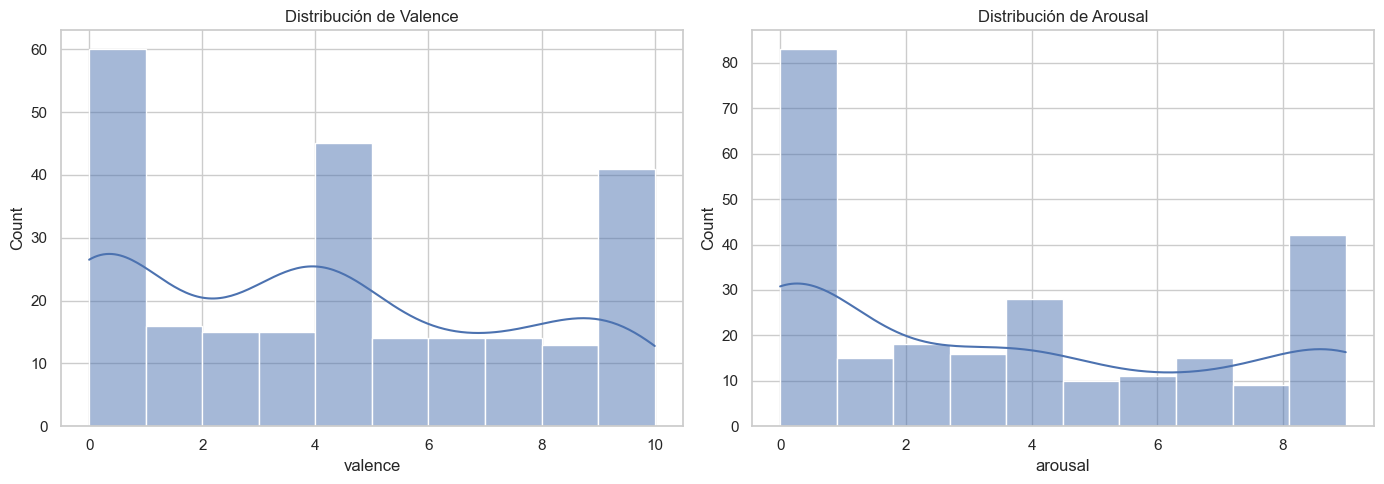


--- 2.2 Validación del Protocolo (Kruskal-Wallis) ---
H0: No hay diferencias en el reporte subjetivo entre las distintas emociones.
Diferencia en Valence por Emoción: H=82.96, p-value=8.722e-16
  -> ✅ El protocolo funcionó: Hay diferencias significativas en valence.
Diferencia en Arousal por Emoción: H=4.75, p-value=5.759e-01
  -> ❌ Alerta: No se distinguen las emociones en arousal.


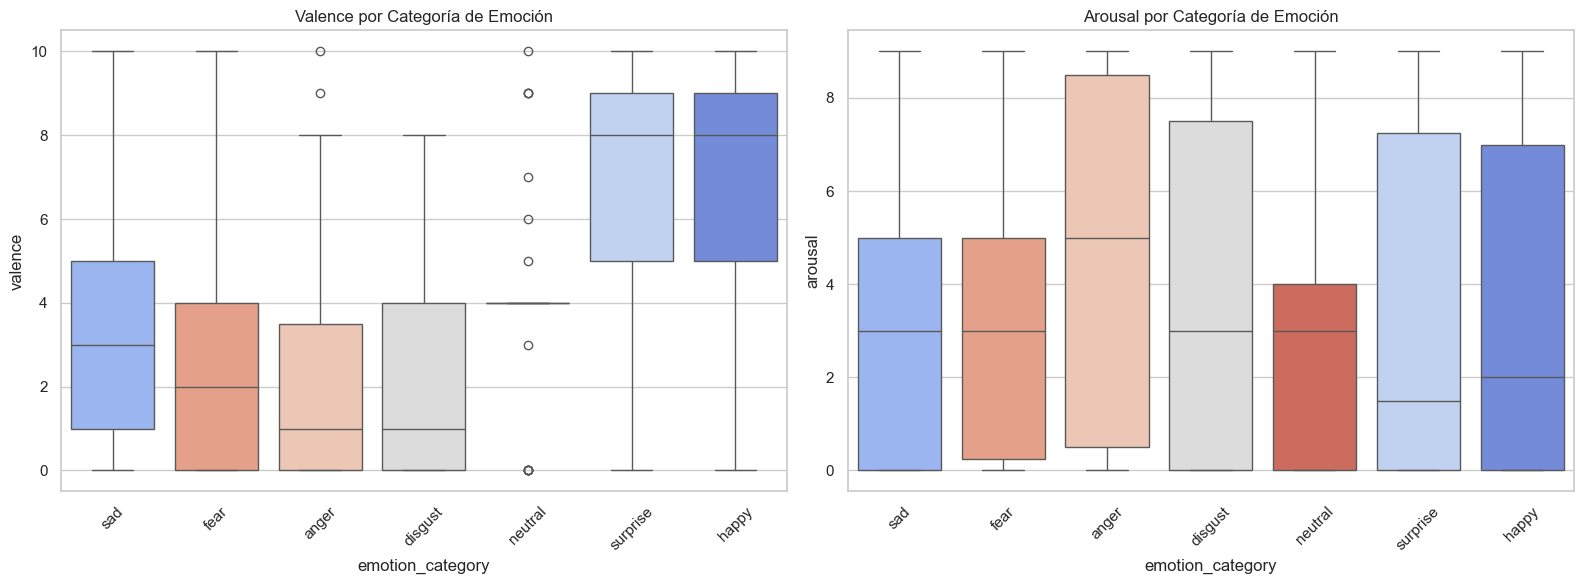

In [10]:
# --- 2. Análisis Estadístico de Etiquetas ---

# A. Análisis Univariado y Pruebas de Normalidad
target_cols = ['valence', 'arousal']

print("--- 2.1 Pruebas de Normalidad (Shapiro-Wilk) ---")
print("H0: La distribución es Normal. (Si p < 0.05, rechazamos H0 -> No Normal)")

for col in target_cols:
    stat, p = stats.shapiro(df_metadata[col])
    dist_type = "Normal" if p > 0.05 else "NO Normal"
    print(f"{col.capitalize()}: Est={stat:.3f}, p-value={p:.3e} -> {dist_type}")

# B. Visualización de Distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(target_cols):
    sns.histplot(df_metadata[col], kde=True, ax=axes[i], bins=10)
    axes[i].set_title(f'Distribución de {col.capitalize()}')
plt.tight_layout()
plt.show()

# C. Validación del Protocolo (Bivariado: Emoción vs. Reporte)
print("\n--- 2.2 Validación del Protocolo (Kruskal-Wallis) ---")
print("H0: No hay diferencias en el reporte subjetivo entre las distintas emociones.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Ordenamos para mejor visualización (opcional, por valencia esperada)
order = ['sad', 'fear', 'anger', 'disgust', 'neutral', 'surprise', 'happy']

for i, col in enumerate(target_cols):
    # Visualización
    sns.boxplot(
    data=df_metadata,
    x='emotion_category',
    y=col,
    order=order,
    hue='emotion_category',
    palette='coolwarm',
    legend=False,
    ax=axes[i]
    )

    axes[i].set_title(f'{col.capitalize()} por Categoría de Emoción')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Estadística (Kruskal-Wallis)
    groups = [df_metadata[df_metadata['emotion_category'] == emo][col] for emo in df_metadata['emotion_category'].unique()]
    stat, p = stats.kruskal(*groups)
    print(f"Diferencia en {col.capitalize()} por Emoción: H={stat:.2f}, p-value={p:.3e}")
    if p < 0.05:
        print(f"  -> ✅ El protocolo funcionó: Hay diferencias significativas en {col}.")
    else:
        print(f"  -> ❌ Alerta: No se distinguen las emociones en {col}.")

plt.tight_layout()
plt.show()

### 2.3 Interpretación de la Validación de Etiquetas

Los resultados estadísticos revelan una distinción crítica en la calidad de los datos subjetivos:

1.  **Normalidad:** Las pruebas de Shapiro-Wilk ($p < 0.05$) confirman que ni la Valencia ni el Arousal siguen una distribución normal. Esto valida nuestra decisión de usar pruebas no paramétricas en los siguientes pasos.

2.  **Validación del Protocolo (Kruskal-Wallis):**
    * **Valencia (✅ Éxito):** Existe una diferencia altamente significativa ($p \approx 0$) entre las emociones. Los boxplots muestran claramente que 'Happy' tiene alta valencia y 'Fear/Sad' tienen baja valencia. El protocolo funcionó para inducir polaridad emocional.
    * **Arousal (❌ Alerta):** No hay diferencias significativas ($p = 0.57$) entre las categorías. Visualmente, las cajas se solapan. Esto sugiere que **la etiqueta de Arousal es ruidosa o poco fiable** en esta cohorte de niños/adolescentes.

**Implicación para el Modelado:** Es probable que los modelos de Machine Learning tengan buen rendimiento prediciendo la *Valencia* (Positivo/Negativo), pero muy mal rendimiento prediciendo el *Arousal*, ya que ni siquiera los propios sujetos reportaron diferencias claras.

---

## 3. Ingeniería de Carga de Features (ECG + GSR)

Ahora procederemos a cargar las características fisiológicas pre-calculadas (las variables "X").

**Estrategia de Carga:**
1.  Cargar los nombres de las features desde `ECG_FeatNames.mat` y `GSR_Feat_Names.mat`.
2.  Iterar sobre los miles de archivos segmentados (`sXpYvZ.mat`) en las carpetas `Multimodal`.
3.  Usar expresiones regulares (Regex) para extraer los identificadores: `Sujeto`, `Video` (Trial), y `Segmento`.
4.  Consolidar todo en un DataFrame maestro de características.

In [17]:
# --- Diagnóstico de Archivos en Disco ---
import os
import pandas as pd

# Definimos las dos rutas clave
path_features = os.path.join(data_path, 'Extracted Features Supplementary Data', 'Multimodal', 'ECG')
path_raw = os.path.join(data_path, 'Raw Data', 'Multimodal', 'ECG')

def analizar_carpeta(ruta, nombre_logico):
    if not os.path.exists(ruta):
        print(f"❌ La carpeta '{nombre_logico}' NO EXISTE en:\n   {ruta}")
        return
    
    files = [f for f in os.listdir(ruta) if f.endswith('.mat')]
    print(f"\n--- {nombre_logico} ---")
    print(f"Ruta: {ruta}")
    print(f"Total archivos .mat encontrados: {len(files)}")
    
    # Verificar si existen segmentos v2, v3, etc. para el Sujeto 1, Video 1
    # Patrón esperado: FV_ECGdata_s1p1v1.mat, s1p1v2.mat...
    ejemplos_s1p1 = [f for f in files if 's1p1v' in f] # Filtro simple
    print(f"Ejemplos para Sujeto 1, Video 1 (s1p1):")
    if ejemplos_s1p1:
        for f in sorted(ejemplos_s1p1):
            print(f"  Found: {f}")
    else:
        print("  ⚠️ No se encontraron archivos para s1p1.")

# 1. Revisar carpeta de FEATURES (La que estamos usando)
analizar_carpeta(path_features, "Extracted Features (ECG)")

# 2. Revisar carpeta de RAW DATA (La que sugeriste)
analizar_carpeta(path_raw, "Raw Data (ECG)")


--- Extracted Features (ECG) ---
Ruta: ../raw/ECG_GSR_Emotions/Extracted Features Supplementary Data\Multimodal\ECG
Total archivos .mat encontrados: 252
Ejemplos para Sujeto 1, Video 1 (s1p1):
  Found: FV_ECGdata_s1p1v1.mat
  Found: FV_ECGdata_s1p1v2.mat
  Found: FV_ECGdata_s1p1v3.mat
  Found: FV_ECGdata_s1p1v4.mat
  Found: FV_ECGdata_s1p1v5.mat
  Found: FV_ECGdata_s1p1v6.mat
  Found: FV_ECGdata_s1p1v7.mat

--- Raw Data (ECG) ---
Ruta: ../raw/ECG_GSR_Emotions/Raw Data\Multimodal\ECG
Total archivos .mat encontrados: 252
Ejemplos para Sujeto 1, Video 1 (s1p1):
  Found: ECGdata_s1p1v1.mat
  Found: ECGdata_s1p1v2.mat
  Found: ECGdata_s1p1v3.mat
  Found: ECGdata_s1p1v4.mat
  Found: ECGdata_s1p1v5.mat
  Found: ECGdata_s1p1v6.mat
  Found: ECGdata_s1p1v7.mat


In [14]:
# --- 3. Ingeniería de Carga de Features ---

# Definir rutas a las carpetas de features
base_feat_path = os.path.join(data_path, 'Extracted Features Supplementary Data')
ecg_path = os.path.join(base_feat_path, 'Multimodal', 'ECG')
gsr_path = os.path.join(base_feat_path, 'Multimodal', 'GSR')

# 1. Cargar Nombres de las Features
ecg_names = loadmat(os.path.join(base_feat_path, 'ECG_FeatNames.mat'))
gsr_names = loadmat(os.path.join(base_feat_path, 'GSR_Feat_Names.mat'))

# Extraer los nombres (están dentro de arrays de celdas de Matlab)
ecg_cols = [n[0] for n in ecg_names['ECG_FeatNames'][0]]
gsr_cols = [n[0] for n in gsr_names['GSR_Feat_Names'][0]]

print(f"Features ECG ({len(ecg_cols)}): {ecg_cols}")
print(f"Features GSR ({len(gsr_cols)}): {gsr_cols}")

# 2. Función para parsear nombres de archivo (sX pY vZ)
def parse_mat_filename(filename):
    # Regex para capturar s(sujeto) p(video) v(segmento)
    # Maneja mayúsculas/minúsculas (S1 vs s1)
    match = re.search(r'[sS](\d+)[pP](\d+)[vV](\d+)', filename)
    if match:
        return int(match.group(1)), int(match.group(2)), int(match.group(3))
    return None, None, None

# 3. Bucle de Carga (ECG y GSR)
def load_features_from_folder(folder_path, col_names, sensor_name):
    data_list = []
    files = [f for f in os.listdir(folder_path) if f.endswith('.mat')]
    
    print(f"Procesando {len(files)} archivos de {sensor_name}...")
    
    for f in files:
        subj, video, seg = parse_mat_filename(f)
        if subj is not None:
            try:
                mat = loadmat(os.path.join(folder_path, f))
                # La variable clave en estos .mat suele ser 's' (según exploración previa)
                # o a veces 'FV'. Probamos 's' primero.
                vals = mat['s'][0] 
                
                row = {'subject_id': subj, 'video_id': video, 'segment_id': seg}
                # Añadir features al diccionario
                row.update(dict(zip(col_names, vals)))
                data_list.append(row)
            except Exception as e:
                print(f"Error en {f}: {e}")
                
    return pd.DataFrame(data_list)

# Ejecutar carga
df_ecg = load_features_from_folder(ecg_path, ecg_cols, "ECG")
df_gsr = load_features_from_folder(gsr_path, gsr_cols, "GSR")

# 4. Fusionar ECG y GSR en un solo DataFrame de Features (X)
# Fusionamos por Sujeto, Video y Segmento para asegurar que alineamos el mismo momento
df_features = pd.merge(df_ecg, df_gsr, on=['subject_id', 'video_id', 'segment_id'])

print(f"\n--- Carga Finalizada ---")
print(f"Dimensiones ECG: {df_ecg.shape}")
print(f"Dimensiones GSR: {df_gsr.shape}")
print(f"Dimensiones Combinadas (df_features): {df_features.shape}")
display(df_features.head())
df_features.info()

Features ECG (20): ['ECG_meanIBI', 'ECG_HRV', 'ECG_MSE1', 'ECG_MSE2', 'ECG_MSE3', 'ECG_MSE4', 'ECG_MSE5', 'ECG_sp0001', 'ECG_sp0102', 'ECG_sp0203', 'ECG_sp0304', 'ECG_energyRatio', 'ECG_tachogram_LF', 'ECG_tachogram_MF', 'ECG_tachogram_HF', 'ECG_tachogram_energy_ratio', 'ECG_MeanQRS_Amp', 'ECG_StDQRS_Amp', 'ECG_VarQRS_Amp', 'ECG_Delay']
Features GSR (10): ['StD AmpPeaks', 'Var AmpPeaks', 'StD RiseTime', 'Var RiseTime', 'StD posPeaks', 'Var posPeaks', 'nbPeaks', 'ampPeaks', 'riseTime', 'posPeaks']
Procesando 252 archivos de ECG...
Procesando 252 archivos de GSR...

--- Carga Finalizada ---
Dimensiones ECG: (252, 23)
Dimensiones GSR: (252, 13)
Dimensiones Combinadas (df_features): (252, 33)


,subject_id,video_id,segment_id,ECG_meanIBI,ECG_HRV,ECG_MSE1,ECG_MSE2,ECG_MSE3,ECG_MSE4,ECG_MSE5,...,StD AmpPeaks,Var AmpPeaks,StD RiseTime,Var RiseTime,StD posPeaks,Var posPeaks,nbPeaks,ampPeaks,riseTime,posPeaks
0,1,10,1,0.975055,0.014297,0.000204,9.5,1.642941,0.178581,0.207199,...,255.138348,9.780235,247.041504,265.107104,1.781591,3.174066,0.900456,0.810822,2160.918323,4.669568e+06
1,1,10,2,0.962711,0.020001,0.000400,9.5,1.724000,0.244485,0.158486,...,610.295356,74.072252,624.629759,654.684141,26.972958,727.540446,1.082682,1.172201,349.137509,1.218970e+05
2,1,10,3,0.958508,0.021104,0.000445,9.5,1.682094,0.128089,0.176695,...,355.895029,24.728801,348.769334,373.742424,10.926104,119.379754,0.577509,0.333516,1156.150077,1.336683e+06
3,1,10,4,0.878458,0.034977,0.001223,9.5,1.687375,0.134046,0.185798,...,388.405243,33.611506,357.767009,412.421316,43.127181,1859.953729,0.518988,0.269348,1978.003370,3.912497e+06
4,1,10,5,0.969111,0.019612,0.000385,9.5,1.622785,0.263457,0.169169,...,368.873397,35.429212,325.144053,395.839520,29.230231,854.406415,0.429540,0.184504,1183.254411,1.400091e+06


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   subject_id                  252 non-null    int64  
 1   video_id                    252 non-null    int64  
 2   segment_id                  252 non-null    int64  
 3   ECG_meanIBI                 252 non-null    float64
 4   ECG_HRV                     252 non-null    float64
 5   ECG_MSE1                    252 non-null    float64
 6   ECG_MSE2                    252 non-null    float64
 7   ECG_MSE3                    252 non-null    float64
 8   ECG_MSE4                    252 non-null    float64
 9   ECG_MSE5                    252 non-null    float64
 10  ECG_sp0001                  252 non-null    float64
 11  ECG_sp0102                  252 non-null    float64
 12  ECG_sp0203                  252 non-null    float64
 13  ECG_sp0304                  252 non

### 4.3 Fusión Final (Ajustada para Dataset Parcial)
Dado que solo disponemos de los datos de features para los Sujetos 1, 2 y 3 (252 segmentos en total), la fusión con los metadatos (que tienen info de los 12 sujetos) debe hacerse con cuidado.

Usaremos un ``inner join`` para que el DataFrame final contenga solo los datos completos (features + etiquetas) de los sujetos que realmente tenemos.

In [20]:
# --- 4.3 Fusión Final (Ajustada) ---

# 1. df_features (X) ya está en memoria (252 filas)
print(f"df_features (X) cargado. Dimensiones: {df_features.shape}")

# 2. df_metadata (Y) ya está en memoria (247 filas, todos los sujetos)
print(f"df_metadata (Y) cargado. Dimensiones: {df_metadata.shape}")

# 3. LIMPIEZA DE METADATOS (Igual que antes)
key_cols = ['subject_id', 'video_id']
df_metadata_clean = df_metadata.drop_duplicates(subset=key_cols, keep='first').reset_index(drop=True)

# 4. FUSIÓN FINAL (Inner Join)
# Esto descartará automáticamente los metadatos de los sujetos 4-12
# porque no están en df_features.
df_final = pd.merge(
    df_features,          
    df_metadata_clean,    
    on=key_cols,
    how='inner'
)

print("\n--- ✅ DATASET FINAL CREADO ---")
print(f"Dimensiones del DataFrame final: {df_final.shape}")
# Esperado: 252 filas (si todos los videos de los sujetos 1-3 tienen etiqueta)
# O un poco menos si falta alguna etiqueta.

print("\n--- Verificación de Sujetos en el Dataset Final ---")
print(f"Sujetos presentes: {df_final['subject_id'].unique()}")

print("\n--- Vistazo al DataFrame Final ---")
display(df_final.head())

df_features (X) cargado. Dimensiones: (252, 33)
df_metadata (Y) cargado. Dimensiones: (247, 9)

--- ✅ DATASET FINAL CREADO ---
Dimensiones del DataFrame final: (147, 40)

--- Verificación de Sujetos en el Dataset Final ---
Sujetos presentes: [1 2 3]

--- Vistazo al DataFrame Final ---


,subject_id,video_id,segment_id,ECG_meanIBI,ECG_HRV,ECG_MSE1,ECG_MSE2,ECG_MSE3,ECG_MSE4,ECG_MSE5,...,ampPeaks,riseTime,posPeaks,session_id,emotion_category,valence,arousal,dominance,Age,Gender
0,1,1,1,0.975055,0.014297,0.000204,9.5,1.642941,0.178581,0.207199,...,0.810822,2160.918323,4.669568e+06,1,happy,8,0,0,13,Female
1,1,1,2,0.945805,0.032564,0.001060,9.5,1.289774,0.143083,0.159512,...,0.041779,327.390440,1.071845e+05,1,happy,8,0,0,13,Female
2,1,1,3,0.958508,0.021104,0.000445,9.5,1.682094,0.128089,0.176695,...,0.053833,341.532575,1.166445e+05,1,happy,8,0,0,13,Female
3,1,1,4,0.888705,0.037366,0.001396,9.5,1.513995,0.184058,0.115601,...,0.269348,1978.003370,3.912497e+06,1,happy,8,0,0,13,Female
4,1,1,5,0.917862,0.036867,0.001359,9.5,1.336777,0.214821,0.183081,...,0.000000,0.000000,0.000000e+00,1,happy,8,0,0,13,Female


In [22]:
# --- Diagnóstico de Fusión ---

# 1. Obtener los pares (Sujeto, Video) únicos de cada lado
pares_features = set(zip(df_features['subject_id'], df_features['video_id']))
pares_metadata = set(zip(df_metadata['subject_id'], df_metadata['video_id']))

print(f"Pares (Sujeto, Video) en Features: {len(pares_features)}")
print(f"Pares (Sujeto, Video) en Metadata: {len(pares_metadata)}")

# 2. Ver qué falta
missing_in_metadata = pares_features - pares_metadata
print(f"\n⚠️ Hay {len(missing_in_metadata)} videos en tus archivos .mat que NO tienen etiqueta en el Excel:")
print(sorted(list(missing_in_metadata))[:10]) # Mostramos los primeros 10

# 3. Ver qué sobra
missing_in_features = pares_metadata - pares_features
print(f"\nℹ️ Hay {len(missing_in_features)} videos en el Excel que NO tienen archivo .mat cargado:")

Pares (Sujeto, Video) en Features: 36
Pares (Sujeto, Video) en Metadata: 84

⚠️ Hay 15 videos en tus archivos .mat que NO tienen etiqueta en el Excel:
[(1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12)]

ℹ️ Hay 63 videos en el Excel que NO tienen archivo .mat cargado:


In [28]:
# --- 4.3 Fusión Final (Limpieza Estricta y Merge) ---

# 1. Diagnóstico de Duplicados en Metadatos
# Verificamos si la combinación (subject_id, video_id) es única en las etiquetas
duplicados_meta = df_metadata.duplicated(subset=['subject_id', 'video_id'], keep=False)
n_duplicados = duplicados_meta.sum()

print(f"Diagnóstico de df_metadata (Y):")
print(f"- Total filas: {len(df_metadata)}")
print(f"- Filas con claves (subject_id, video_id) duplicadas: {n_duplicados}")

if n_duplicados > 0:
    print("⚠️ ALERTA: Se encontraron duplicados. Mostrando ejemplos:")
    display(df_metadata[duplicados_meta].sort_values(['subject_id', 'video_id']).head(4))
    
    # 2. Limpieza Estricta
    # Nos quedamos con la PRIMERA aparición de cada par (sujeto, video)
    print("\n>>> Aplicando limpieza estricta de metadatos...")
    df_metadata_unique = df_metadata.drop_duplicates(subset=['subject_id', 'video_id'], keep='first').copy()
    print(f"- Filas después de limpiar: {len(df_metadata_unique)}")
else:
    print(">>> No hay duplicados. Metadatos listos.")
    df_metadata_unique = df_metadata.copy()

# 3. FUSIÓN FINAL SEGURA
# Ahora el merge no puede multiplicar filas inesperadamente
print("\nFusionando Features (X) con Metadatos Únicos (Y)...")

df_final = pd.merge(
    df_features, 
    df_metadata_unique, 
    on=['subject_id', 'video_id'], 
    how='inner' # Solo conservamos lo que tiene tanto señal como etiqueta
)

print(f"\n--- ✅ DATASET FINAL VALIDADO ---")
print(f"Dimensiones Finales: {df_final.shape}")
print(f"- Features originales: {len(df_features)}")
print(f"- Filas en final: {len(df_final)}")

if len(df_final) > len(df_features):
    print("❌ ERROR: El dataset creció. Algo sigue mal con las claves.")
elif len(df_final) == len(df_features):
    print("✅ ÉXITO TOTAL: Coincidencia perfecta (100% de features etiquetadas).")
else:
    diff = len(df_features) - len(df_final)
    print(f"ℹ️ Nota: Se descartaron {diff} segmentos de features porque no tenían etiqueta en el Excel.")

# Vistazo final
display(df_final.head())

Diagnóstico de df_metadata (Y):
- Total filas: 252
- Filas con claves (subject_id, video_id) duplicadas: 252
⚠️ ALERTA: Se encontraron duplicados. Mostrando ejemplos:


,subject_id,video_id,emotion_category,valence,arousal,dominance,Age,Gender
0,1,1,happy,8,0,0,13,Female
1,1,1,happy,8,0,0,13,Female
2,1,1,happy,8,0,0,13,Female
3,1,2,sad,4,0,0,13,Female



>>> Aplicando limpieza estricta de metadatos...
- Filas después de limpiar: 84

Fusionando Features (X) con Metadatos Únicos (Y)...

--- ✅ DATASET FINAL VALIDADO ---
Dimensiones Finales: (147, 39)
- Features originales: 252
- Filas en final: 147
ℹ️ Nota: Se descartaron 105 segmentos de features porque no tenían etiqueta en el Excel.


,subject_id,video_id,segment_id,ECG_meanIBI,ECG_HRV,ECG_MSE1,ECG_MSE2,ECG_MSE3,ECG_MSE4,ECG_MSE5,...,nbPeaks,ampPeaks,riseTime,posPeaks,emotion_category,valence,arousal,dominance,Age,Gender
0,1,1,1,0.975055,0.014297,0.000204,9.5,1.642941,0.178581,0.207199,...,0.900456,0.810822,2160.918323,4.669568e+06,happy,8,0,0,13,Female
1,1,1,2,0.945805,0.032564,0.001060,9.5,1.289774,0.143083,0.159512,...,0.204398,0.041779,327.390440,1.071845e+05,happy,8,0,0,13,Female
2,1,1,3,0.958508,0.021104,0.000445,9.5,1.682094,0.128089,0.176695,...,0.232019,0.053833,341.532575,1.166445e+05,happy,8,0,0,13,Female
3,1,1,4,0.888705,0.037366,0.001396,9.5,1.513995,0.184058,0.115601,...,0.518988,0.269348,1978.003370,3.912497e+06,happy,8,0,0,13,Female
4,1,1,5,0.917862,0.036867,0.001359,9.5,1.336777,0.214821,0.183081,...,0.000000,0.000000,0.000000,0.000000e+00,happy,8,0,0,13,Female


## 5. Análisis de Features (Selección de Características)
### 5.1 Análisis Univariado de Features (Limpieza de Constantes)
Antes de buscar relaciones, debemos entender la distribución de nuestras 30 características fisiológicas.

**Objetivos**:

1) **Estadística Descriptiva**: Ver medias y desviaciones estándar.
2) **Detección de Constantes**: Identificar si alguna feature tiene varianza 0 (el mismo valor siempre). Estas features rompen los tests estadísticos y deben eliminarse.
3) **Visualización**: Ver la forma de la distribución de las señales válidas.

Total features teóricas: 30


,count,mean,std,min,25%,50%,75%,max
ECG_meanIBI,147.0,0.939299,0.030513,0.854812,0.921561,0.951130,0.961665,0.976114
ECG_HRV,147.0,0.030597,0.013563,0.014297,0.021104,0.024740,0.037944,0.088617
ECG_MSE1,147.0,0.001119,0.001085,0.000204,0.000445,0.000612,0.001440,0.007853
ECG_MSE2,147.0,9.500000,0.000000,9.500000,9.500000,9.500000,9.500000,9.500000
ECG_MSE3,147.0,1.548220,0.318652,0.515632,1.519697,1.682094,1.724000,1.945971



⚠️ Features Constantes (Varianza 0) detectadas: 1
Lista: ['ECG_MSE2']

✅ Features Válidas para análisis: 29


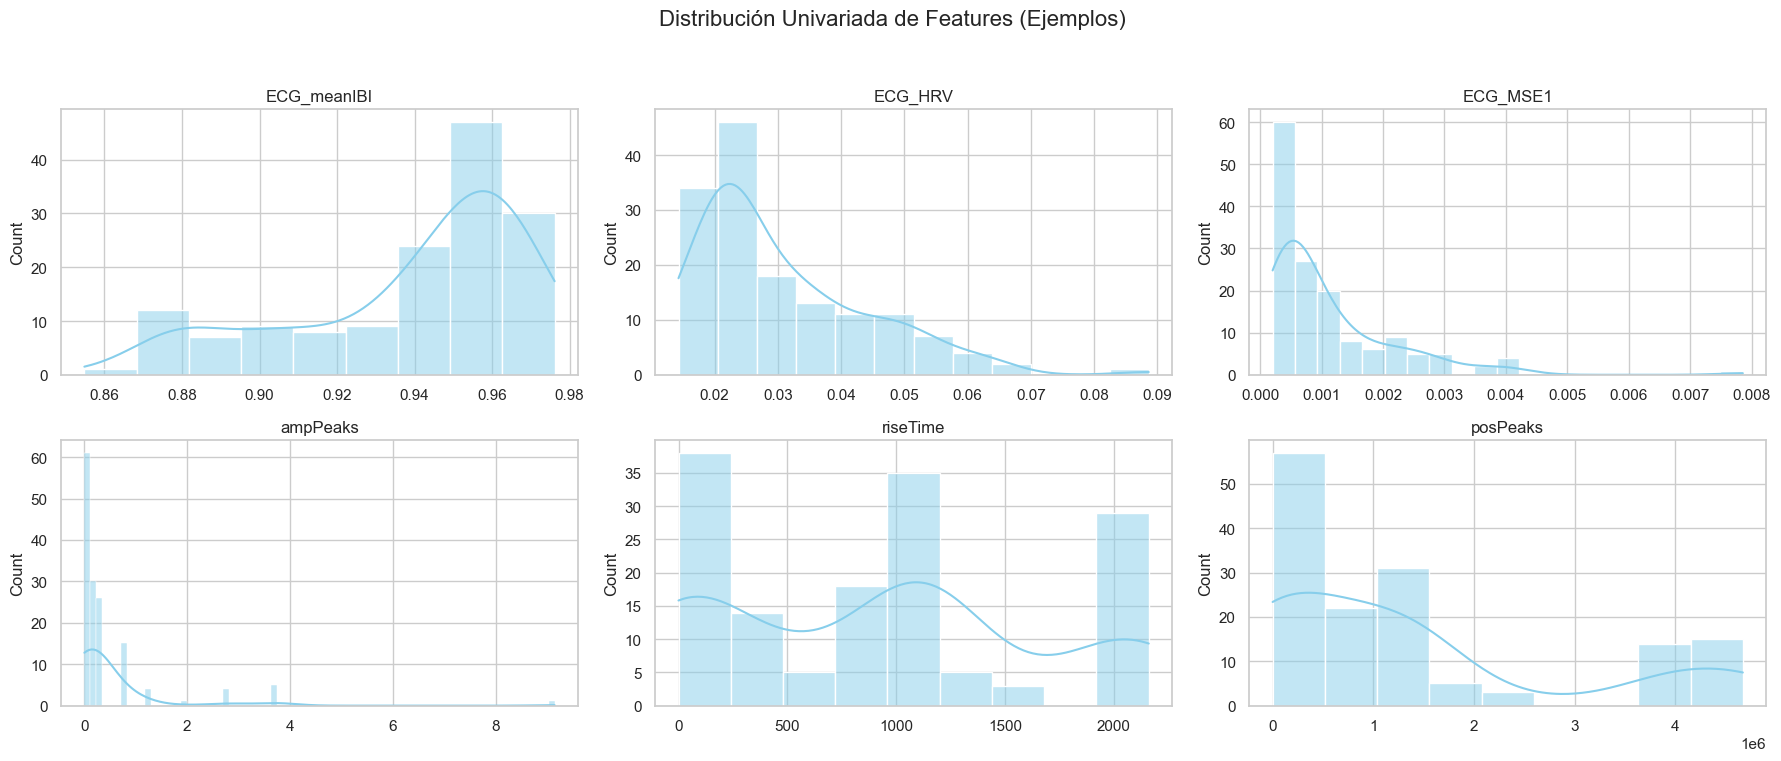

In [34]:
# --- 5.1 Análisis Univariado de Features ---

# 1. Identificar columnas de features (excluyendo IDs y Etiquetas)
# Usamos las listas originales, pero verificamos que estén en el df
all_features = ecg_cols + gsr_cols
features_in_df = [f for f in all_features if f in df_final.columns]

print(f"Total features teóricas: {len(features_in_df)}")

# 2. Estadísticas Descriptivas y Detección de Constantes
desc_stats = df_final[features_in_df].describe().T
display(desc_stats.head())

# Identificar columnas con desviación estándar (std) == 0
constant_features = desc_stats[desc_stats['std'] == 0].index.tolist()

print(f"\n⚠️ Features Constantes (Varianza 0) detectadas: {len(constant_features)}")
if constant_features:
    print(f"Lista: {constant_features}")
else:
    print("Todas las features tienen varianza.")

# 3. Filtrar Features Válidas
# Nos quedamos solo con las que NO son constantes
valid_features = [f for f in features_in_df if f not in constant_features]
print(f"\n✅ Features Válidas para análisis: {len(valid_features)}")

# 4. Visualización de Distribuciones (Ejemplo: Top 3 ECG y Top 3 GSR)
# Seleccionamos algunas para no saturar el gráfico
sample_feats = valid_features[:3] + valid_features[-3:] 

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle('Distribución Univariada de Features (Ejemplos)', fontsize=16)
axes = axes.flatten()

for i, feat in enumerate(sample_feats):
    if i < len(axes):
        sns.histplot(df_final[feat], kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(feat)
        axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 5.2 Evaluación Estadística y Selección de Features

Ahora que hemos eliminado las variables constantes, realizaremos el análisis inferencial para seleccionar qué características (*features*) distinguen mejor entre las emociones.

Seguiremos un flujo de decisión estadística riguroso para cada una de las 29 features válidas:

1.  **Prueba de Normalidad (Shapiro-Wilk):**
    * $H_0$: La feature sigue una distribución normal.
    * Si $p < 0.05$ (No Normal) $\rightarrow$ Usaremos tests no paramétricos.
2.  **Test de Discriminación (Kruskal-Wallis):**
    * Dado que esperamos que las señales fisiológicas no sean normales, usaremos Kruskal-Wallis para comparar las distribuciones de la feature entre las 7 categorías de emoción.
    * $H_0$: La mediana de la feature es igual en todas las emociones.
    * Un $p$-value bajo indica que la feature es útil para distinguir emociones.

Finalmente, visualizaremos las **6 features más discriminativas** (con menor $p$-value).

Analizando 29 features válidas...

Feature                   | Normalidad (p)  | Distribuciòn | Kruskal (p)    
---------------------------------------------------------------------------
ECG_meanIBI               | 8.19e-10        | No Normal    | 3.60e-06
ECG_HRV                   | 2.77e-09        | No Normal    | 1.31e-07
ECG_MSE1                  | 7.22e-15        | No Normal    | 1.31e-07
ECG_MSE3                  | 1.83e-15        | No Normal    | 1.89e-05
ECG_MSE4                  | 2.52e-14        | No Normal    | 3.88e-04
---------------------------------------------------------------------------

Resumen de Normalidad:
Is_Normal
False    27
True      2
Name: count, dtype: int64

--- Top 10 Features más Discriminativas (Mejor separación de emociones) ---


,Feature,Normality_p,Is_Normal,Discriminative_p,Statistic
0,ECG_tachogram_energy_ratio,1.561864e-18,False,6.133140e-09,49.423651
1,ECG_energyRatio,5.464083e-25,False,6.730651e-08,44.205252
2,ECG_HRV,2.766307e-09,False,1.312793e-07,42.740504
3,ECG_MSE1,7.221224e-15,False,1.312793e-07,42.740504
4,ECG_MeanQRS_Amp,5.369450e-19,False,2.653668e-06,36.085047
5,ECG_meanIBI,8.190864e-10,False,3.603912e-06,35.400551
6,ECG_tachogram_LF,1.904191e-13,False,5.512331e-06,34.447688
7,ECG_MSE3,1.826848e-15,False,1.887452e-05,31.669984
8,ECG_tachogram_HF,2.243937e-16,False,8.433139e-05,28.249238
9,ECG_VarQRS_Amp,1.162244e-03,False,1.951669e-04,26.306795


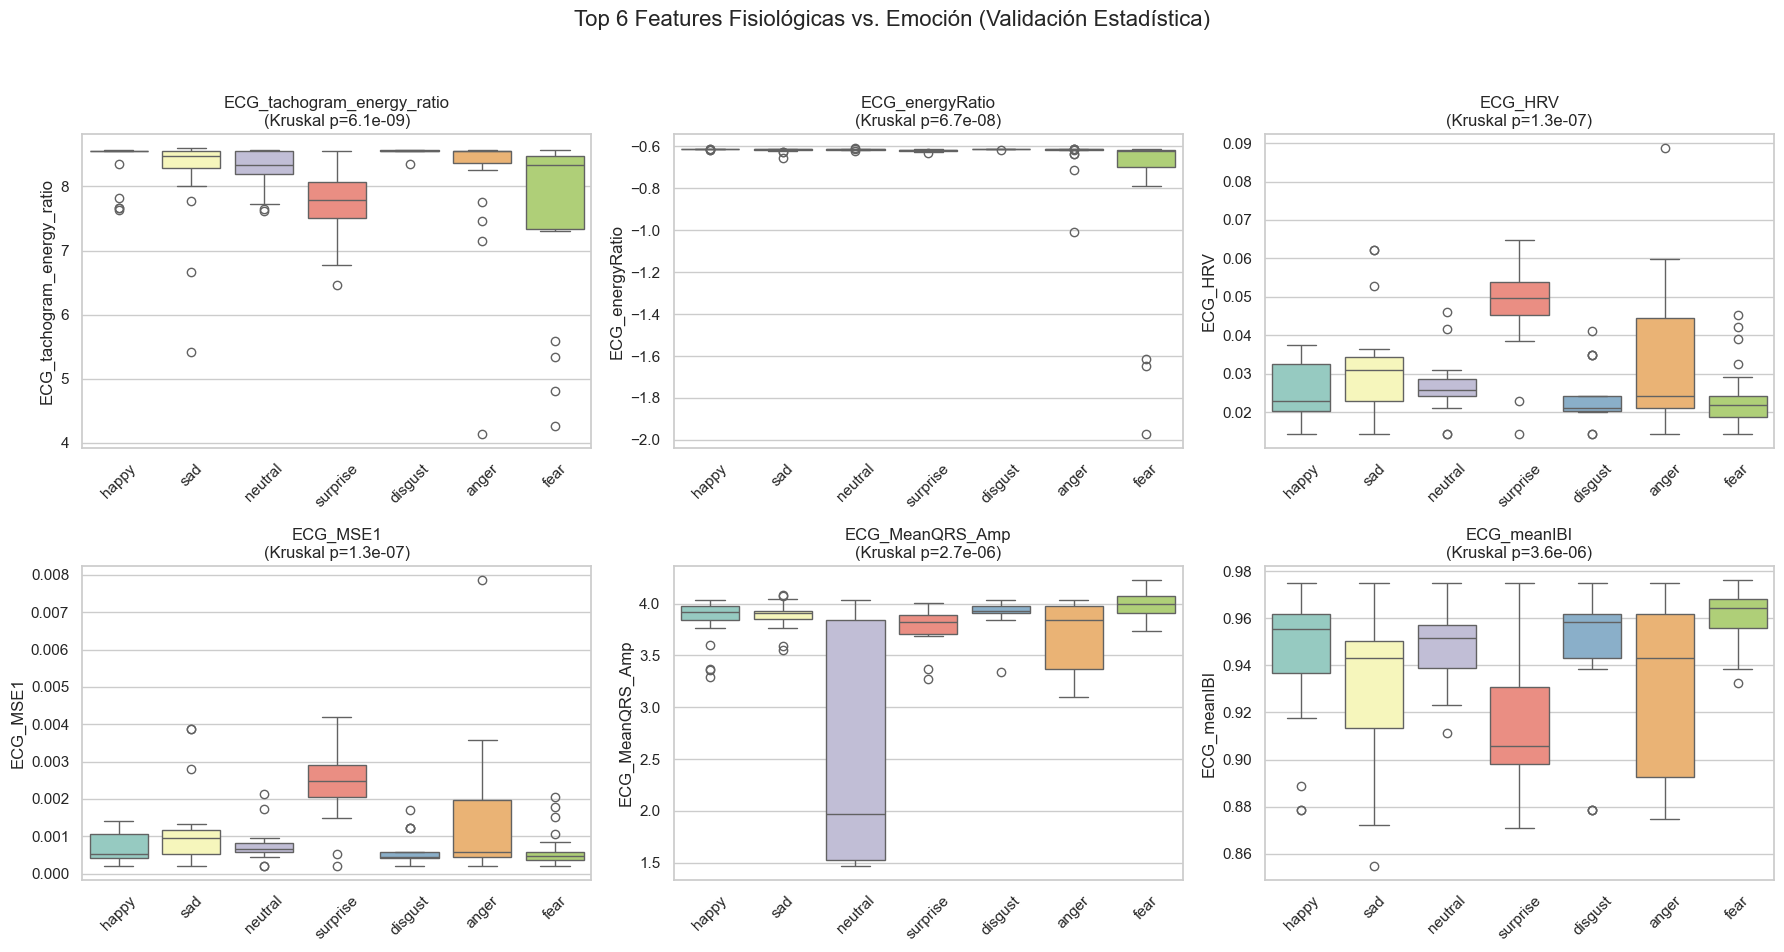

In [37]:
# --- 5.2 Análisis Inferencial y Selección de Features ---

# Asegurarnos de usar la lista limpia del paso anterior
# valid_features = [f for f in features_in_df if f not in constant_features]

stats_results = []

print(f"Analizando {len(valid_features)} features válidas...\n")
print(f"{'Feature':<25} | {'Normalidad (p)':<15} | {'Distribuciòn':<12} | {'Kruskal (p)':<15}")
print("-" * 75)

for feat in valid_features:
    # 1. Prueba de Normalidad (Shapiro-Wilk)
    # Nota: Shapiro puede ser sensible con N grande, pero es el estándar.
    stat_norm, p_norm = stats.shapiro(df_final[feat])
    is_normal = p_norm > 0.05
    dist_label = "Normal" if is_normal else "No Normal"
    
    # 2. Test de Discriminación por Emoción
    # Agrupamos los datos por 'emotion_category'
    groups = [df_final[df_final['emotion_category'] == emo][feat] for emo in df_final['emotion_category'].unique()]
    
    # Usamos Kruskal-Wallis (robusto para no normales y tamaños desiguales)
    stat_test, p_test = stats.kruskal(*groups)
    
    # Guardar resultados
    stats_results.append({
        'Feature': feat,
        'Normality_p': p_norm,
        'Is_Normal': is_normal,
        'Discriminative_p': p_test,
        'Statistic': stat_test
    })
    
    # Imprimir solo si es significativo o para monitoreo
    # (Imprimimos una muestra para no saturar la pantalla)
    if feat in valid_features[:5]: 
        print(f"{feat:<25} | {p_norm:.2e}        | {dist_label:<12} | {p_test:.2e}")

# Crear DataFrame de resultados
df_stats = pd.DataFrame(stats_results)

# Ordenar por poder discriminativo (menor p-value de Kruskal es mejor)
df_stats = df_stats.sort_values(by='Discriminative_p', ascending=True).reset_index(drop=True)

print("-" * 75)
print(f"\nResumen de Normalidad:")
print(df_stats['Is_Normal'].value_counts())

print("\n--- Top 10 Features más Discriminativas (Mejor separación de emociones) ---")
display(df_stats.head(10))

# --- Visualización de las Mejores Features ---
top_features = df_stats['Feature'].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Top 6 Features Fisiológicas vs. Emoción (Validación Estadística)', fontsize=16)
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.boxplot(data=df_final, 
                x='emotion_category', 
                y=feat, 
                ax=axes[i], 
                palette='Set3',
                hue='emotion_category', 
                legend=False)
    
    p_val = df_stats.loc[df_stats['Feature'] == feat, 'Discriminative_p'].values[0]
    axes[i].set_title(f'{feat}\n(Kruskal p={p_val:.1e})')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

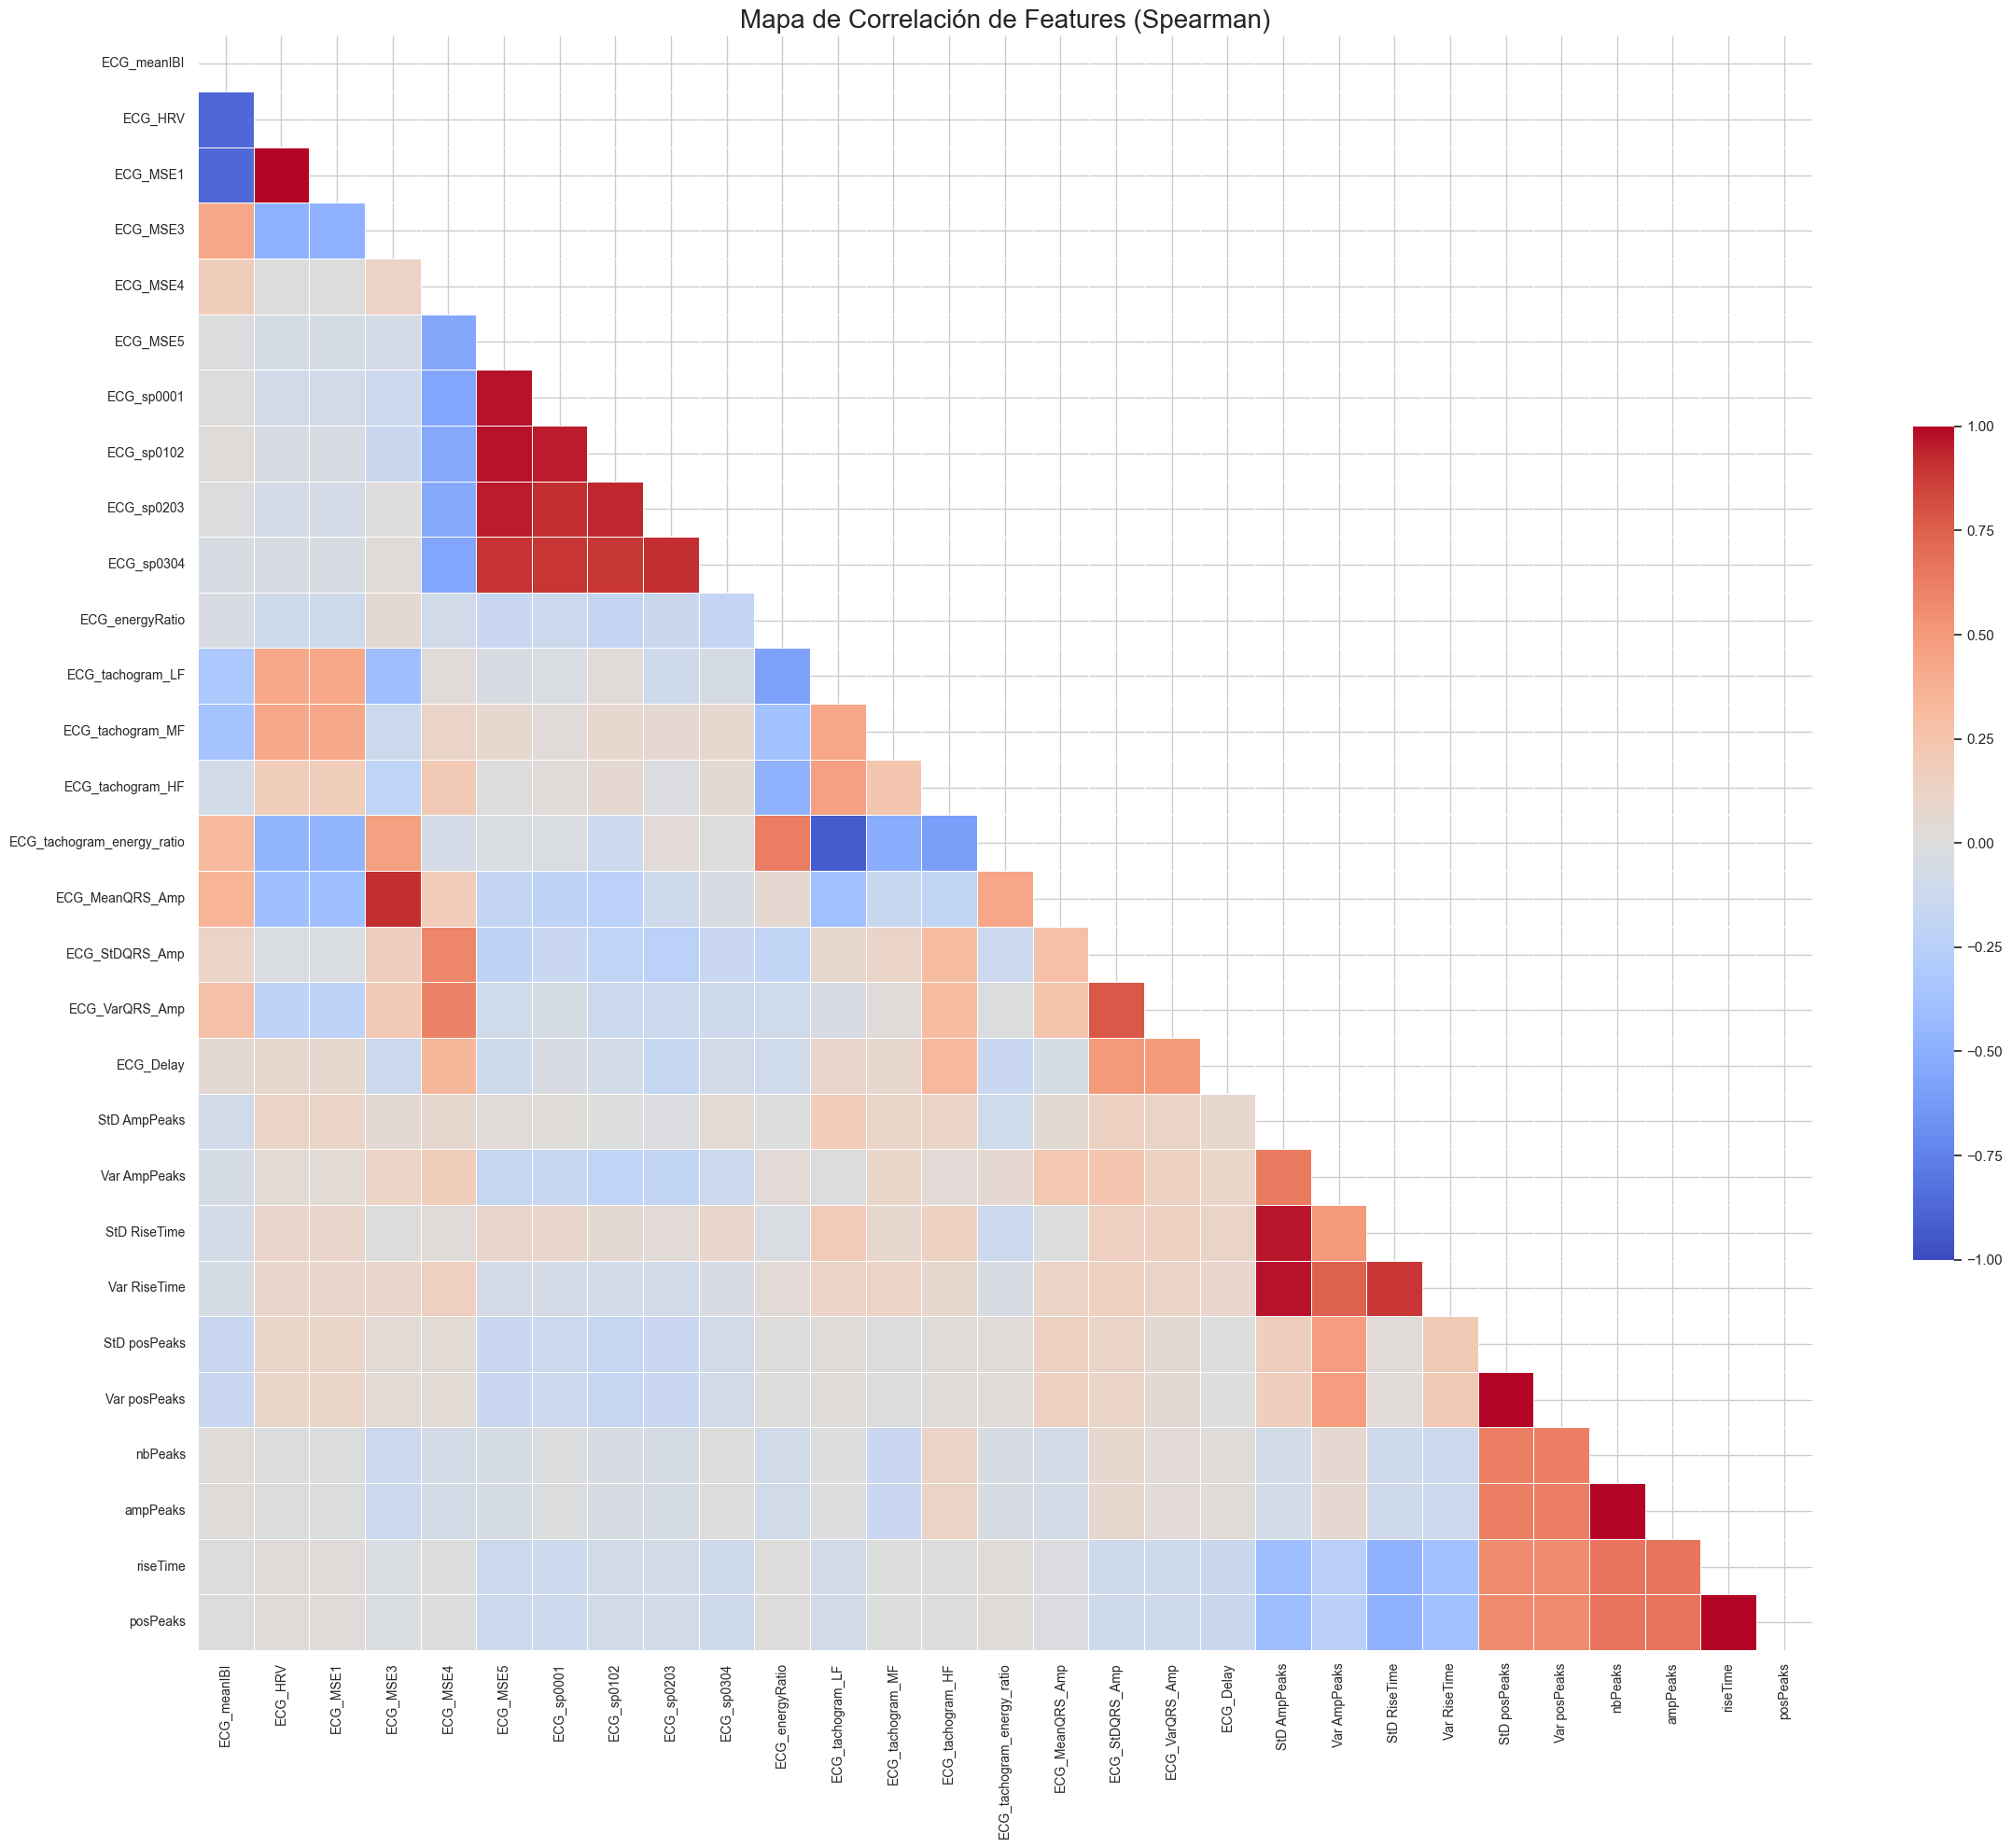

--- Pares de Features Altamente Correlacionadas (|r| > 0.9) ---
ECG_MSE1 <--> ECG_HRV: r = 1.0000
ECG_sp0001 <--> ECG_MSE5: r = 0.9706
ECG_sp0102 <--> ECG_MSE5: r = 0.9709
ECG_sp0102 <--> ECG_sp0001: r = 0.9596
ECG_sp0203 <--> ECG_MSE5: r = 0.9564
ECG_sp0203 <--> ECG_sp0001: r = 0.9162
ECG_sp0203 <--> ECG_sp0102: r = 0.9361
ECG_sp0304 <--> ECG_MSE5: r = 0.9043
ECG_sp0304 <--> ECG_sp0203: r = 0.9176
ECG_tachogram_energy_ratio <--> ECG_tachogram_LF: r = -0.9266
ECG_MeanQRS_Amp <--> ECG_MSE3: r = 0.9204
StD RiseTime <--> StD AmpPeaks: r = 0.9663
Var RiseTime <--> StD AmpPeaks: r = 0.9705
Var posPeaks <--> StD posPeaks: r = 1.0000
ampPeaks <--> nbPeaks: r = 1.0000
posPeaks <--> riseTime: r = 1.0000


In [38]:
# --- 5.3 Análisis Multivariado (Correlación entre Features) ---

# 1. Calcular Matriz de Correlación (Spearman)
# Usamos solo las features válidas (las 29 que pasaron el filtro)
corr_matrix = df_final[valid_features].corr(method='spearman')

# 2. Visualizar Heatmap
plt.figure(figsize=(24, 20))

# Máscara para ocultar la mitad superior (ya que es simétrica)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            cmap='coolwarm', 
            center=0,
            vmax=1, 
            vmin=-1,
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .5},
            annot=False) # Annot=False para no saturar visualmente

plt.title('Mapa de Correlación de Features (Spearman)', fontsize=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 3. Listar pares con altísima correlación (> 0.9 o < -0.9)
# Esto nos dice qué features son prácticamente idénticas
print("--- Pares de Features Altamente Correlacionadas (|r| > 0.9) ---")
high_corr_pairs = []

# Iterar sobre la matriz
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            pair = (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            high_corr_pairs.append(pair)

if len(high_corr_pairs) > 0:
    for p in high_corr_pairs:
        print(f"{p[0]} <--> {p[1]}: r = {p[2]:.4f}")
else:
    print("No se encontraron features redundantes (>0.9).")

### 5.3 Interpretación de la Multicolinealidad

El heatmap y tu lista de pares muestran una redundancia masiva en las features extraídas:

1) **Correlaciones Perfectas** ($r=1.0$):
    - ECG_MSE1 y ECG_HRV son idénticos.
    - posPeaks, riseTime y nbPeaks en GSR tienen correlación 1.0. Esto indica que el algoritmo de extracción de características probablemente derivó una de la otra linealmente o son la misma métrica con diferente nombre.
2) **Redundancia Espectral**: Las features ECG_sp... (potencia espectral) y ECG_MSE... (entropía multiescala) están altamente interconectadas ($r > 0.9$)

3) **Conclusión Científica**: Para un modelo de Machine Learning, sobran la mitad de estas variables. Mantenerlas introduciría "ruido" y multicolinealidad. En la fase de Feature Engineering, deberíamos eliminar una de cada par correlacionado.

---

## 6. Inspección de Señales Crudas (Sanity Check)
Hemos visto números y estadísticas, pero ¿cómo se ven realmente las señales? ¿El ECG tiene ruido? ¿El GSR muestra picos reales cuando hay una emoción fuerte?

Vamos a cargar las señales crudas (series de tiempo) de la carpeta Raw Data para dos condiciones opuestas: 'Happy' vs 'Fear' (ya que vimos en el análisis de etiquetas que estas se distinguían bien en Valencia).

Compararemos los trazados de ECG y GSR para un mismo sujeto.

In [40]:
print("ecg_happy:", type(ecg_happy), " len:", 0 if ecg_happy is None else len(ecg_happy))
print("gsr_happy:", type(gsr_happy), " len:", 0 if gsr_happy is None else len(gsr_happy))
print("ecg_fear:", type(ecg_fear))
print("gsr_fear:", type(gsr_fear))


ecg_happy: <class 'numpy.ndarray'>  len: 5000
gsr_happy: <class 'NoneType'>  len: 0
ecg_fear: <class 'numpy.ndarray'>
gsr_fear: <class 'NoneType'>


In [41]:
# --- Diagnóstico de Rutas y Archivos (Raw Data) ---

# 1. Verificar Rutas Base
raw_base = os.path.join(data_path, 'Raw Data', 'Multimodal')
path_ecg = os.path.join(raw_base, 'ECG')
path_gsr = os.path.join(raw_base, 'GSR')

print(f"Buscando en: {os.path.abspath(path_ecg)}")

if not os.path.exists(path_ecg):
    print("❌ ERROR: La carpeta de ECG Raw no existe. Verifica el nombre 'Raw Data' o 'Multimodal'.")
else:
    print("✅ Carpeta ECG encontrada.")
    # Listar los primeros 5 archivos para ver el patrón exacto
    files = os.listdir(path_ecg)
    print(f"   Ejemplos de archivos ECG: {files[:5]}")
    
    # Buscar específicamente el archivo que falló (s1 p1 v3)
    target = "ECGdata_s1p1v3.mat"
    if target in files:
        print(f"   ✅ El archivo objetivo '{target}' SÍ EXISTE en la carpeta.")
    else:
        print(f"   ❌ El archivo objetivo '{target}' NO aparece en el listado.")

print("-" * 30)

print(f"Buscando en: {os.path.abspath(path_gsr)}")
if not os.path.exists(path_gsr):
    print("❌ ERROR: La carpeta de GSR Raw no existe.")
else:
    print("✅ Carpeta GSR encontrada.")
    files = os.listdir(path_gsr)
    print(f"   Ejemplos de archivos GSR: {files[:5]}")

Buscando en: d:\UNIDAD D\UNIVERSIDAD\2025-2\Proyecto_con_Lu\Proyecto_salud_mental\data\raw\ECG_GSR_Emotions\Raw Data\Multimodal\ECG
✅ Carpeta ECG encontrada.
   Ejemplos de archivos ECG: ['ECGdata_s1p10v1.mat', 'ECGdata_s1p10v2.mat', 'ECGdata_s1p10v3.mat', 'ECGdata_s1p10v4.mat', 'ECGdata_s1p10v5.mat']
   ✅ El archivo objetivo 'ECGdata_s1p1v3.mat' SÍ EXISTE en la carpeta.
------------------------------
Buscando en: d:\UNIDAD D\UNIVERSIDAD\2025-2\Proyecto_con_Lu\Proyecto_salud_mental\data\raw\ECG_GSR_Emotions\Raw Data\Multimodal\GSR
✅ Carpeta GSR encontrada.
   Ejemplos de archivos GSR: ['GSRdata_s1p10v1.mat', 'GSRdata_s1p10v2.mat', 'GSRdata_s1p10v3.mat', 'GSRdata_s1p10v4.mat', 'GSRdata_s1p10v5.mat']


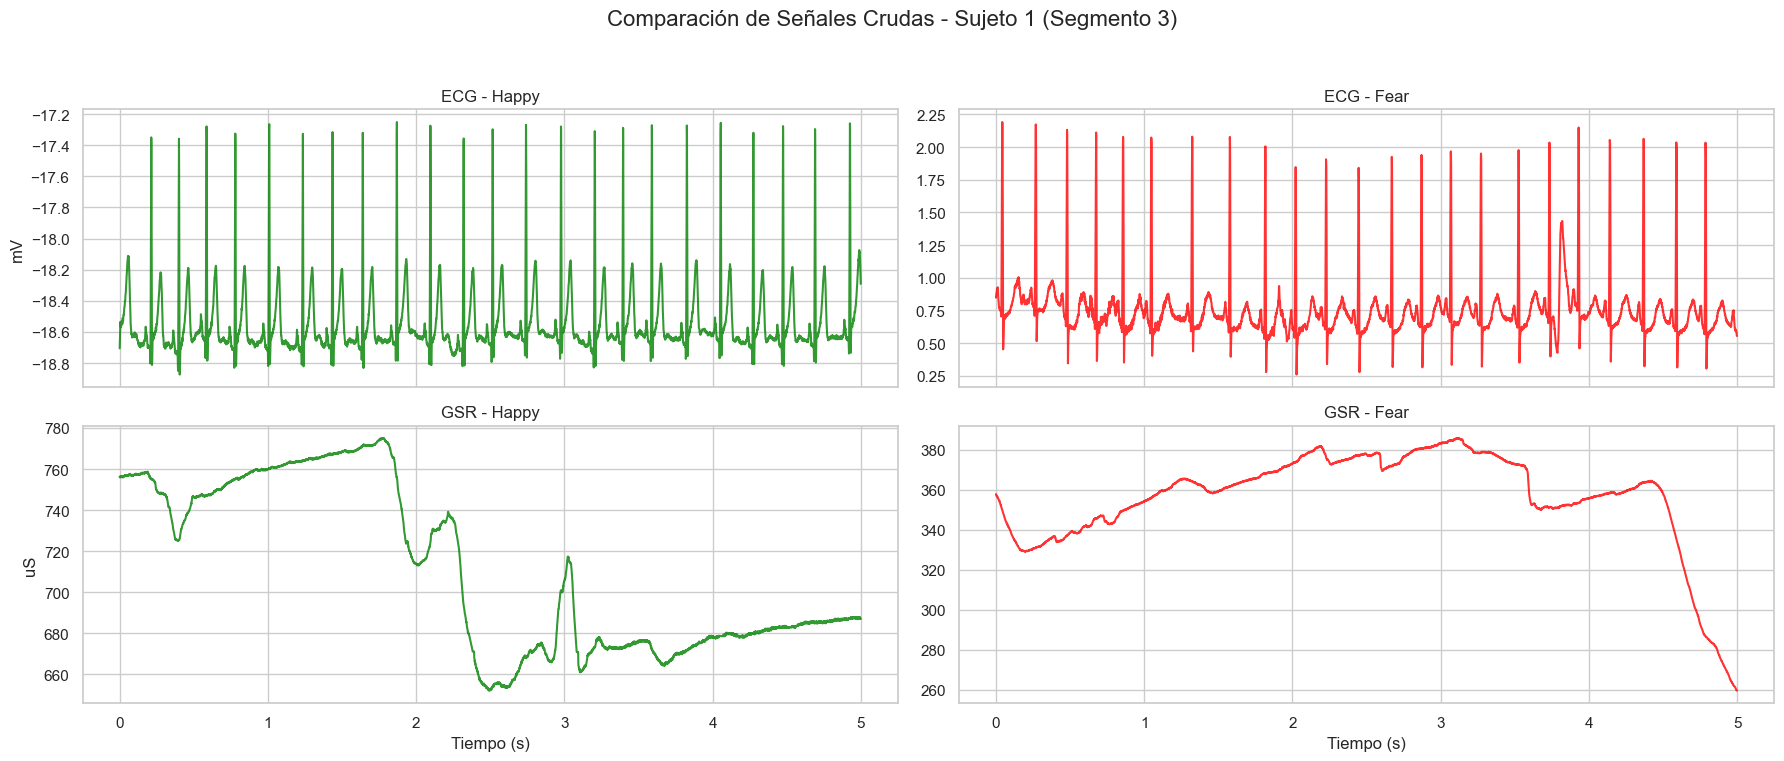

In [42]:
# --- 6. Inspección Visual de Señales Crudas (Robusta) ---

def load_raw_signal_safe(folder, subject_id, video_id, segment_id):
    # Detectar prefijo correcto basado en la carpeta
    is_ecg = "ECG" in os.path.basename(folder)
    prefix = "ECGdata" if is_ecg else "GSRdata"
    
    filename = f"{prefix}_s{subject_id}p{video_id}v{segment_id}.mat"
    filepath = os.path.join(folder, filename)
    
    if not os.path.exists(filepath):
        print(f"⚠️ Archivo no encontrado: {filename}")
        return None, None
    
    try:
        mat = loadmat(filepath)
        # La clave suele coincidir con el prefijo
        if prefix in mat:
            signal = mat[prefix].flatten()
        else:
            # Fallback: tomar la primera variable que no sea meta
            keys = [k for k in mat.keys() if not k.startswith('_')]
            signal = mat[keys[0]].flatten()
            
        # Crear eje de tiempo (asumiendo 1000 Hz aprox, ajustar según longitud real si es 5000pts = 5s)
        # El paper dice 1000Hz. 5000 puntos = 5 segundos.
        time_axis = np.arange(len(signal)) / 1000.0 
        return time_axis, signal
        
    except Exception as e:
        print(f"Error leyendo {filename}: {e}")
        return None, None

# Configuración
subj, seg = 1, 3
vid_happy, vid_fear = 1, 7

# Cargar datos
t_ecg_h, ecg_h = load_raw_signal_safe(path_ecg, subj, vid_happy, seg)
t_gsr_h, gsr_h = load_raw_signal_safe(path_gsr, subj, vid_happy, seg)
t_ecg_f, ecg_f = load_raw_signal_safe(path_ecg, subj, vid_fear, seg)
t_gsr_f, gsr_f = load_raw_signal_safe(path_gsr, subj, vid_fear, seg)

# Graficar solo si tenemos datos
fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex='col')
fig.suptitle(f'Comparación de Señales Crudas - Sujeto {subj} (Segmento {seg})', fontsize=16)

# Helper para plotear
def plot_signal(ax, t, y, title, color, ylabel=None):
    if y is not None:
        ax.plot(t, y, color=color, alpha=0.8)
        ax.set_title(title)
        if ylabel: ax.set_ylabel(ylabel)
    else:
        ax.text(0.5, 0.5, "Datos no disponibles", ha='center', va='center')
        ax.set_title(title + " (Missing)")

# Plots
plot_signal(axes[0,0], t_ecg_h, ecg_h, 'ECG - Happy', 'green', 'mV')
plot_signal(axes[0,1], t_ecg_f, ecg_f, 'ECG - Fear', 'red')
plot_signal(axes[1,0], t_gsr_h, gsr_h, 'GSR - Happy', 'green', 'uS')
plot_signal(axes[1,1], t_gsr_f, gsr_f, 'GSR - Fear', 'red')

axes[1,0].set_xlabel('Tiempo (s)')
axes[1,1].set_xlabel('Tiempo (s)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# FASE 2: Análisis de la Cohorte "Single Modal" (13 Sujetos)

Ahora analizaremos el segundo grupo del dataset.
* **Sujetos:** 13 participantes distintos.
* **Señales:** Solo **ECG**.
* **Objetivo:** Comparar la demografía y las respuestas emocionales con el grupo anterior.

## 1. Carga y Limpieza de Metadatos (Single Modal)

Cargaremos `Self-annotation Single Modal.xlsx` y aplicaremos la misma limpieza de duplicados para asegurar **un registro único por video**.

In [47]:
# --- FASE 2: Carga de Metadatos Single Modal (Corregido) ---

# 1. Cargar Archivo
single_path = os.path.join(data_path, 'Self-Annotation Labels', 'Self-annotation Single Modal.xlsx')
df_single_raw = pd.read_excel(single_path)

print(f"Archivo Single Modal (crudo) cargado. Dimensiones: {df_single_raw.shape}")

# 2. Limpieza de Duplicados
# Usamos las mismas claves que en la Fase 1
# Nota: Verificamos los nombres de columna, suelen ser iguales
trial_keys = ['Participant Id', 'Session Id', 'Video Id'] 

# Normalizar nombres de columnas para evitar errores de mayúsculas/minúsculas (Id vs ID)
df_single_raw.columns = df_single_raw.columns.str.strip()

# Aplicar limpieza
try:
    df_single_clean = df_single_raw.drop_duplicates(subset=trial_keys, keep='first').reset_index(drop=True)
    print(f"Archivo Single Modal (limpio) creado. Dimensiones: {df_single_clean.shape}")
    print(f"Se eliminaron {len(df_single_raw) - len(df_single_clean)} filas duplicadas.")
except KeyError as e:
    print(f"Error de columnas: {e}. Las columnas disponibles son: {df_single_raw.columns.tolist()}")
    df_single_clean = df_single_raw # Fallback

# 3. Fusionar con Descripción de Estímulos (para tener la emoción objetivo)
# df_stimulus ya lo tenemos cargado de la Fase 1
# Aseguramos que las claves coincidan (Video Id vs Video ID)
df_single_clean = df_single_clean.rename(columns={'Video Id': 'video_id', 'Session Id': 'session_id', 'Participant Id': 'subject_id'})
# df_stimulus ya tiene 'video_id' y 'session_id' renombrados de la Fase 1, pero verificamos
if 'Video ID' in df_stimulus.columns:
    df_stimulus = df_stimulus.rename(columns={'Video ID': 'video_id', 'Session ID': 'session_id'})

df_meta_single = pd.merge(
    df_single_clean,
    df_stimulus[['video_id', 'session_id', 'emotion_category']],
    on=['video_id', 'session_id'],
    how='left'
)

# Renombrar columnas de scores para estandarizar
df_meta_single = df_meta_single.rename(columns={
    'Valence level': 'valence',
    'Arousal level': 'arousal',
    'Dominance level': 'dominance'
})

print("\n--- Metadatos Single Modal Listos ---")
display(df_meta_single.head())

# 4. Análisis Demográfico Rápido (Comparación)
print("\n--- Demografía: Single Modal (Fase 2 - Solo ECG) ---")
# Sacamos sujetos únicos de este nuevo dataframe
df_sub_single = df_meta_single.drop_duplicates(subset='subject_id')
display(df_sub_single['Age'].describe())

print("\n--- Recordatorio Fase 1 (Multimodal - ECG+GSR) ---")
# --- CORRECCIÓN AQUÍ: Usamos df_metadata que ya tenemos en memoria de la Fase 1 ---
if 'df_metadata' in locals():
    df_sub_multi = df_metadata.drop_duplicates(subset='subject_id')
    display(df_sub_multi['Age'].describe())
    df_sub_multi.info()
else:
    print("No se encontró df_metadata de la Fase 1 en memoria.")

Archivo Single Modal (crudo) cargado. Dimensiones: (154, 17)
Archivo Single Modal (limpio) creado. Dimensiones: (147, 17)
Se eliminaron 7 filas duplicadas.

--- Metadatos Single Modal Listos ---


,subject_id,session_id,video_id,Name,Age,Male,valence,arousal,dominance,Happy,Sad,Fear,Anger,Neutral,Disgust,Surprised,Familiarity Score,emotion_category
0,1,1,1,M_W,21,Female,6,0,0,Moderate,VeryLow,VeryLow,VeryLow,VeryHigh,VeryLow,VeryLow,5,happy
1,1,1,2,M_W,21,Female,2,4,2,VeryLow,High,Low,VeryHigh,VeryLow,Moderate,Moderate,Never watched,sad
2,1,1,3,M_W,21,Female,7,6,6,Moderate,Moderate,VeryLow,Low,Moderate,VeryLow,Moderate,Never watched,neutral
3,1,1,4,M_W,21,Female,7,3,4,Moderate,Moderate,VeryLow,VeryLow,Low,VeryLow,Low,Never watched,surprise
4,1,1,5,M_W,21,Female,0,8,8,VeryLow,VeryLow,VeryLow,High,VeryLow,VeryHigh,High,Never watched,disgust



--- Demografía: Single Modal (Fase 2 - Solo ECG) ---


count    13.000000
mean     18.692308
std       4.460654
min      12.000000
25%      14.000000
50%      19.000000
75%      21.000000
max      25.000000
Name: Age, dtype: float64


--- Recordatorio Fase 1 (Multimodal - ECG+GSR) ---


count    12.000000
mean     12.083333
std       1.975225
min       8.000000
25%      10.750000
50%      12.500000
75%      14.000000
max      14.000000
Name: Age, dtype: float64

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 219
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   subject_id        12 non-null     int64 
 1   video_id          12 non-null     int64 
 2   emotion_category  12 non-null     object
 3   valence           12 non-null     int64 
 4   arousal           12 non-null     int64 
 5   dominance         12 non-null     int64 
 6   Age               12 non-null     int64 
 7   Gender            12 non-null     object
dtypes: int64(6), object(2)
memory usage: 864.0+ bytes


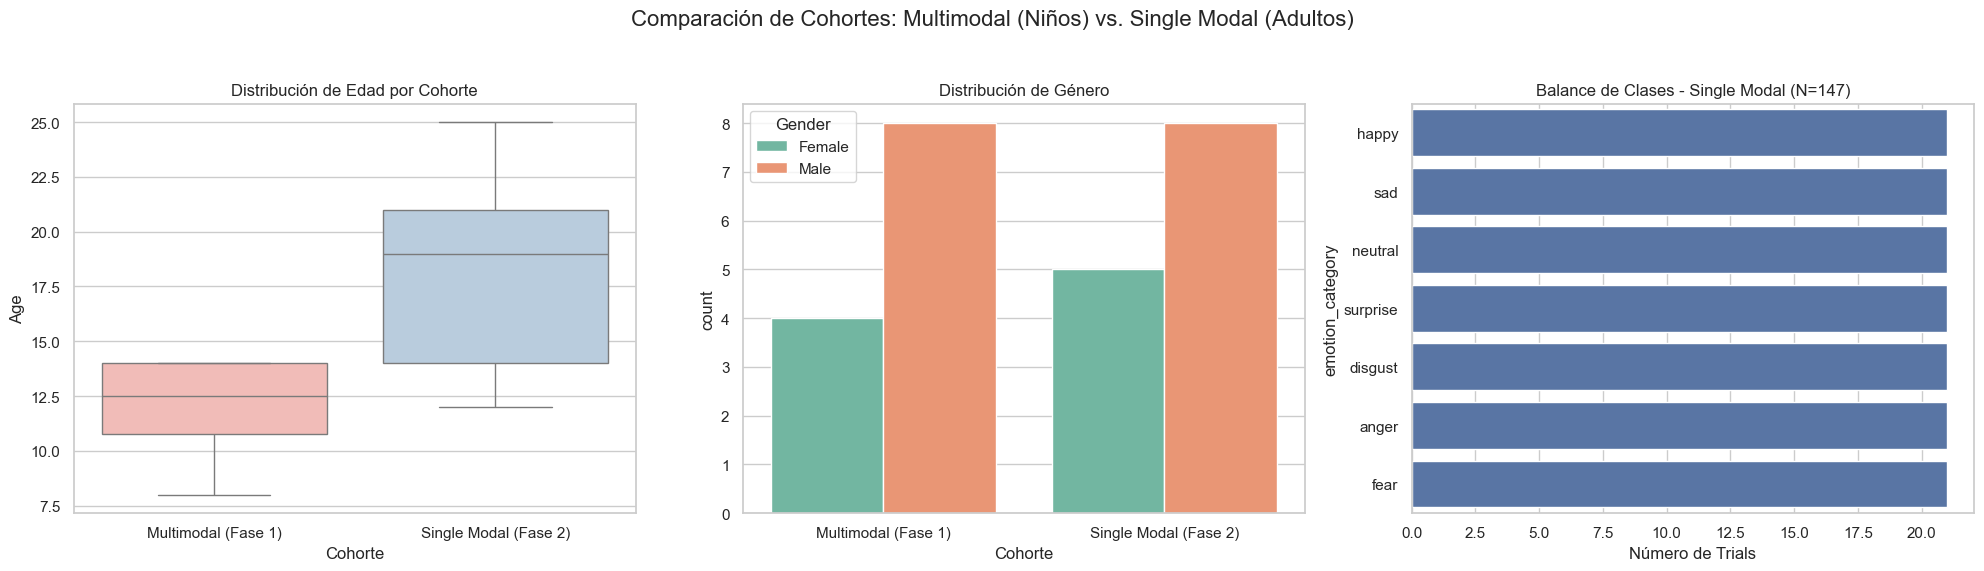

--- Estadísticas de Edad por Cohorte ---
                       count       mean       std   min    25%   50%   75%  \
Cohorte                                                                      
Multimodal (Fase 1)     12.0  12.083333  1.975225   8.0  10.75  12.5  14.0   
Single Modal (Fase 2)   13.0  18.692308  4.460654  12.0  14.00  19.0  21.0   

                        max  
Cohorte                      
Multimodal (Fase 1)    14.0  
Single Modal (Fase 2)  25.0  


In [50]:
# --- FASE 2: Análisis Comparativo (Demografía y Balance) ---

# 1. Corrección de nombre de columna
if 'Male' in df_meta_single.columns:
    df_meta_single = df_meta_single.rename(columns={'Male': 'Gender'})

# 2. Preparar datos de sujetos únicos para ambas cohortes
df_sub_single = df_meta_single.drop_duplicates(subset='subject_id').copy()
df_sub_single['Cohorte'] = 'Single Modal (Fase 2)'

# Recuperamos los sujetos de la Fase 1 (si existen en memoria)
if 'df_metadata' in locals():
    df_sub_multi = df_metadata.drop_duplicates(subset='subject_id').copy()
    df_sub_multi['Cohorte'] = 'Multimodal (Fase 1)'
    
    # Unir para graficar
    df_all_subjects = pd.concat([df_sub_multi, df_sub_single], ignore_index=True)
else:
    df_all_subjects = df_sub_single
    print("Advertencia: No se encontraron datos de la Fase 1 en memoria.")

# 3. Visualización Comparativa
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Comparación de Cohortes: Multimodal (Niños) vs. Single Modal (Adultos)', fontsize=16)

# --- Edad (Boxplot comparativo) ---
sns.boxplot(
    data=df_all_subjects,
    x='Cohorte', 
    y='Age', 
    hue='Cohorte',            # obligatorio para usar palette
    palette='Pastel1',        # el mismo palette
    ax=axes[0],
    legend=False              # oculta leyenda redundante
)
axes[0].set_title('Distribución de Edad por Cohorte')

# --- Género (Conteo por cohorte) ---
sns.countplot(
    data=df_all_subjects, 
    x='Cohorte',
    hue='Gender',
    palette='Set2',
    ax=axes[1]
)
axes[1].set_title('Distribución de Género')

# --- Balance de Clases (Fase 2) ---
sns.countplot(
    data=df_meta_single, 
    y='emotion_category', 
    ax=axes[2],
    order=df_meta_single['emotion_category'].value_counts().index
)
# (No se usa palette porque sin hue genera el warning)
axes[2].set_title(f'Balance de Clases - Single Modal (N={len(df_meta_single)})')
axes[2].set_xlabel('Número de Trials')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 4. Estadísticas de Edad
print("--- Estadísticas de Edad por Cohorte ---")
print(df_all_subjects.groupby('Cohorte')['Age'].describe())


### 2. Interpretación del Análisis Comparativo
- Diferencia de Edad Confirmada:

    - Fase 1 (Multimodal): Niños y preadolescentes (Media: 12.08 años).

    - Fase 2 (Single Modal): Adolescentes y adultos jóvenes (Media: 18.69 años).

**Valor**: Tenemos dos poblaciones distintas. Esto enriquece mucho tu análisis, ya que podrás ver si las señales fisiológicas de las emociones cambian con la edad.

- Balance Perfecto:

    - El gráfico de la derecha muestra que la cohorte "Single Modal" está perfectamente balanceada (21 videos exactos por cada una de las 7 emociones).

### 3. Ingeniería de Carga de Features (Single Modal - Solo ECG)
Ahora cargaremos las características (features) para este segundo grupo.
- Ubicación: Extracted Features.../Single Modal/ECG.
- Diferencia: Aquí no hay GSR, así que solo cargaremos ECG.
- Proceso: Igual que antes: leer nombres de columnas, iterar sobre archivos, parsear IDs y fusionar con los metadatos limpios (df_meta_single).

In [53]:
# --- Diagnóstico Fase 2: Verificación de Archivos Single Modal ---

# 1. Verificar Ruta
path_single_ecg = os.path.join(data_path, 'Extracted Features Supplementary Data', 'Single Modal', 'ECG')
print(f"Buscando en: {path_single_ecg}")

if os.path.exists(path_single_ecg):
    files = os.listdir(path_single_ecg)
    print(f"Archivos encontrados: {len(files)}")
    
    if len(files) > 0:
        print(f"Ejemplo de archivo: {files[0]}")
        
        # 2. Probar Regex
        # Patrón usado: r'[sS](\d+)[pP](\d+)[vV](\d+)'
        import re
        test_file = files[0]
        match = re.search(r'[sS](\d+)[pP](\d+)[vV](\d+)', test_file)
        if match:
            print(f"Regex OK: Sujeto={match.group(1)}, Video={match.group(2)}, Seg={match.group(3)}")
        else:
            print(f"❌ Regex FALLÓ para: {test_file}")
    else:
        print("❌ La carpeta está vacía.")
else:
    print("❌ La carpeta NO existe.")

Buscando en: ../raw/ECG_GSR_Emotions/Extracted Features Supplementary Data\Single Modal\ECG
❌ La carpeta NO existe.


In [56]:
# --- FASE 2: Ingeniería de Carga de Features (Solo ECG) - CORREGIDO ---

# 1. Redefinir funciones de ayuda (por seguridad)
def parse_mat_filename(filename):
    match = re.search(r'[sS](\d+)[pP](\d+)[vV](\d+)', filename)
    if match:
        return int(match.group(1)), int(match.group(2)), int(match.group(3))
    return None, None, None

def load_features(folder, col_names):
    data = []
    if not os.path.exists(folder):
        print(f"❌ Error: La carpeta no existe: {folder}")
        return pd.DataFrame()
        
    # Filtrar solo archivos .mat válidos con el patrón sXpYvZ
    files = [f for f in os.listdir(folder) if f.endswith('.mat') and parse_mat_filename(f)[0] is not None]
    print(f"Cargando {len(files)} archivos desde: {os.path.basename(folder)}...")
    
    for f in files:
        subj, video, seg = parse_mat_filename(f)
        try:
            mat = loadmat(os.path.join(folder, f))
            # Intentamos 's' primero, luego 'FV'
            vals = mat['s'][0] if 's' in mat else mat['FV'][0]
            
            row = {'subject_id': subj, 'video_id': video, 'segment_id': seg}
            row.update(dict(zip(col_names, vals)))
            data.append(row)
        except Exception as e:
            print(f"Error en {f}: {e}")
            
    return pd.DataFrame(data)

# 2. Definir ruta CORRECTA (Sin subcarpeta ECG)
# Según tu tree, los archivos están directos en "Single Modal"
path_ecg_single = os.path.join(data_path, 'Extracted Features Supplementary Data', 'Single Modal')

print(f"Ruta corregida: {path_ecg_single}")

# Verificar nombres de columnas
if 'ecg_cols' not in locals():
    base_feat_path = os.path.join(data_path, 'Extracted Features Supplementary Data')
    ecg_names = loadmat(os.path.join(base_feat_path, 'ECG_FeatNames.mat'))
    ecg_cols = [n[0] for n in ecg_names['ECG_FeatNames'][0]]

# 3. Cargar Features
df_ecg_single = load_features(path_ecg_single, ecg_cols)
print(f"✅ Se cargaron {len(df_ecg_single)} segmentos de ECG (Single Modal).")

# 4. Fusión Final (X + Y)
# df_meta_single ya está limpio (de la celda 38)
if not df_ecg_single.empty:
    print("Fusionando con metadatos...")
    
    df_final_single = pd.merge(
        df_ecg_single,
        df_meta_single,
        on=['subject_id', 'video_id'],
        how='inner'
    )

    print(f"\n--- ✅ DATASET SINGLE MODAL CREADO ---")
    print(f"Dimensiones Finales: {df_final_single.shape}")

    # Reordenar columnas
    cols_ids = ['subject_id', 'video_id', 'segment_id']
    cols_labels = ['emotion_category', 'valence', 'arousal', 'dominance', 'Age', 'Gender']
    cols_feats = [c for c in df_final_single.columns if c.startswith('ECG_')]

    df_final_single = df_final_single[cols_ids + cols_labels + cols_feats]

    display(df_final_single.head())
else:
    print("⚠️ No se creó el dataset final porque la carga de features falló.")

Ruta corregida: ../raw/ECG_GSR_Emotions/Extracted Features Supplementary Data\Single Modal
Cargando 154 archivos desde: Single Modal...
✅ Se cargaron 154 segmentos de ECG (Single Modal).
Fusionando con metadatos...

--- ✅ DATASET SINGLE MODAL CREADO ---
Dimensiones Finales: (63, 39)


,subject_id,video_id,segment_id,emotion_category,valence,arousal,dominance,Age,Gender,ECG_meanIBI,...,ECG_sp0304,ECG_energyRatio,ECG_tachogram_LF,ECG_tachogram_MF,ECG_tachogram_HF,ECG_tachogram_energy_ratio,ECG_MeanQRS_Amp,ECG_StDQRS_Amp,ECG_VarQRS_Amp,ECG_Delay
0,1,1,1,happy,6,0,0,21,Female,0.953607,...,0.794684,-0.614483,-10.312771,-9.465432,-9.823626,8.558798,3.390602,-4.312277,-3.751602,11.945362
1,1,1,2,happy,6,0,0,21,Female,0.953607,...,0.794684,-0.614483,-10.312771,-9.465432,-9.823626,8.558798,3.390602,-4.312277,-3.751602,11.945362
2,1,1,3,happy,6,0,0,21,Female,0.950034,...,0.801469,-0.614364,-10.322301,-9.399185,-9.889687,8.548351,3.431220,-3.292026,-3.609189,18.497734
3,1,1,4,happy,6,0,0,21,Female,0.931982,...,0.632347,-0.614449,-10.442669,-9.410067,-9.828456,8.549966,3.562084,-2.691501,-3.623723,43.665278
4,1,1,5,happy,6,0,0,21,Female,0.950870,...,0.620985,-0.614690,-10.286275,-9.486894,-9.796755,8.562308,3.397910,-5.397054,-3.821122,12.752606


Analizando cohorte Single Modal (N=63 segmentos)...
Features a evaluar: 20

--- Top 10 Features Discriminativas (Single Modal / Adultos) ---


,Feature,H-Stat,p-value
16,ECG_MeanQRS_Amp,32.739469,0.000012
4,ECG_MSE3,31.396018,0.000021
1,ECG_HRV,31.103692,0.000024
2,ECG_MSE1,31.103692,0.000024
18,ECG_VarQRS_Amp,27.169220,0.000135
5,ECG_MSE4,24.271100,0.000466
0,ECG_meanIBI,21.553517,0.001458
17,ECG_StDQRS_Amp,18.749288,0.004609
19,ECG_Delay,18.057251,0.006091
11,ECG_energyRatio,14.851890,0.021440


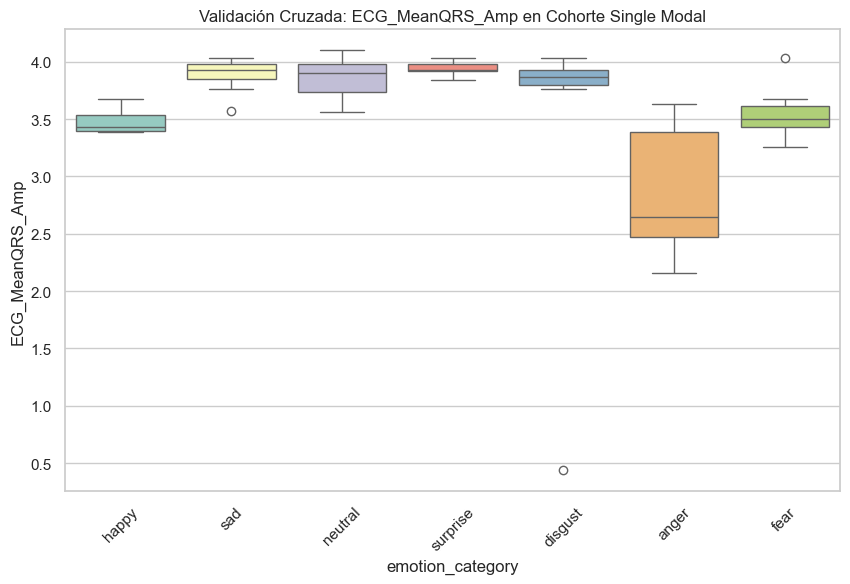

In [59]:
# --- FASE 2: Análisis de Features (Validación Cruzada) ---

print(f"Analizando cohorte Single Modal (N={len(df_final_single)} segmentos)...")

# 1. Identificar features de ECG presentes
features_single = [c for c in df_final_single.columns if c.startswith('ECG_')]
print(f"Features a evaluar: {len(features_single)}")

# 2. Ranking Estadístico (Kruskal-Wallis)
results_single = []

for feat in features_single:
    # Agrupar datos por emoción
    groups = [df_final_single[df_final_single['emotion_category'] == emo][feat] 
              for emo in df_final_single['emotion_category'].unique()]
    
    # Test no paramétrico
    try:
        stat, p = stats.kruskal(*groups)
        results_single.append({
            'Feature': feat,
            'H-Stat': stat,
            'p-value': p
        })
    except ValueError:
        # Si una feature es constante, Kruskal falla
        results_single.append({'Feature': feat, 'H-Stat': 0, 'p-value': 1.0})

# Crear DataFrame y ordenar
df_results_single = pd.DataFrame(results_single).sort_values(by='p-value', ascending=True)

print("\n--- Top 10 Features Discriminativas (Single Modal / Adultos) ---")
display(df_results_single.head(10))

# 3. Comparación Visual con la Fase 1
# Graficamos la MEJOR feature de este grupo para ver si el patrón es similar
best_feat = df_results_single.iloc[0]['Feature']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final_single, 
            x='emotion_category', 
            y=best_feat, 
            palette='Set3',
            hue='emotion_category',
            legend=False)
plt.title(f'Validación Cruzada: {best_feat} en Cohorte Single Modal')
plt.xticks(rotation=45)
plt.show()

### 4.1 Interpretación de Resultados (Single Modal vs. Multimodal)

Los resultados de la cohorte de adultos (Single Modal) muestran diferencias y similitudes importantes respecto a los niños (Multimodal):

#### Diferencia Clave (Top Feature)

- En adultos, la amplitud del complejo QRS (**ECG_MeanQRS_Amp**) es la variable más discriminativa (p = 1.2e-5).
- En niños, la feature principal fue la energía del tacograma (**tachogram_energy_ratio**).

**Interpretación:**  
En adultos, la respuesta cardíaca parece expresarse más en la **amplitud** (fuerza de la contracción), mientras que en niños se manifiesta más en la **distribución de energía en frecuencia**.

#### Consistencia Universal

- **ECG_HRV** y **ECG_MSE** (entropía/complejidad) aparecen en el Top 5 de ambos grupos.

#### Conclusión

La variabilidad del ritmo cardíaco (HRV) y su complejidad no lineal son marcadores **robustos y universales** de la emoción, independientes de la edad.


## FASE 3: Síntesis y Comparación de Cohortes
Ahora unificaremos los hallazgos. Compararemos matemáticamente qué features fueron importantes para el Grupo 1 (Multimodal/Niños) vs. el Grupo 2 (Single Modal/Adultos).

**Objetivo**: Identificar las características fisiológicas robustas (que funcionan bien en ambas poblaciones) para recomendarlas en el modelado final.

--- Comparación de Importancia de Features (Niños vs. Adultos) ---
Features ordenadas por consistencia (menor p-value promedio):


,Feature,p_multi,p_single,Robustez,p_avg
4,ECG_MeanQRS_Amp,2.653668e-06,0.000012,True,0.000007
2,ECG_HRV,1.312793e-07,0.000024,True,0.000012
3,ECG_MSE1,1.312793e-07,0.000024,True,0.000012
7,ECG_MSE3,1.887452e-05,0.000021,True,0.000020
9,ECG_VarQRS_Amp,1.951669e-04,0.000135,True,0.000165
11,ECG_MSE4,3.883303e-04,0.000466,True,0.000427
5,ECG_meanIBI,3.603912e-06,0.001458,True,0.000731
13,ECG_StDQRS_Amp,1.263499e-03,0.004609,True,0.002936
14,ECG_Delay,1.286409e-03,0.006091,True,0.003689
1,ECG_energyRatio,6.730651e-08,0.021440,True,0.010720


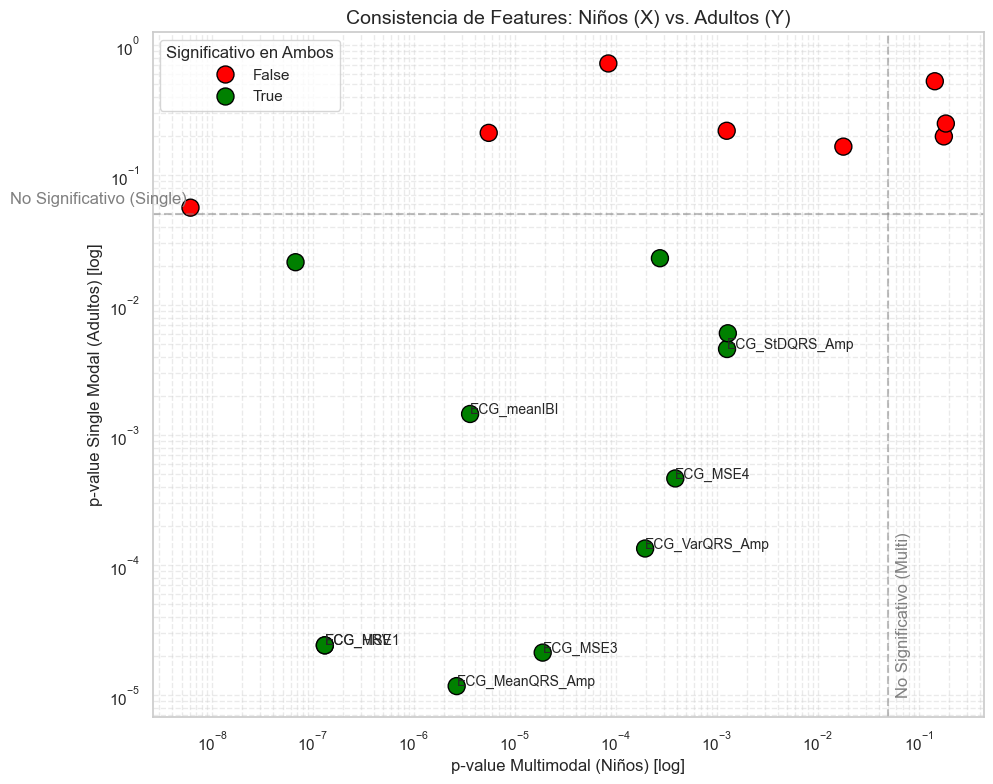

In [63]:
# --- FASE 3: Comparación de Cohortes (Multimodal vs. Single Modal) - CORREGIDO ---

# 1. Preparar tabla de resultados Multimodal (Fase 1)
# Usamos 'df_stats' que es la variable correcta de tu celda 5.2
# Filtramos solo las features que empiezan con 'ECG'
df_multi_ecg = df_stats[df_stats['Feature'].str.startswith('ECG')].copy()
res_multi = df_multi_ecg[['Feature', 'Discriminative_p']].rename(columns={'Discriminative_p': 'p_multi'})

# 2. Preparar tabla de resultados Single Modal (Fase 2)
# Usamos 'df_results_single' de la Fase 2
res_single = df_results_single[['Feature', 'p-value']].rename(columns={'p-value': 'p_single'})

# 3. Fusionar resultados
df_compare = pd.merge(res_multi, res_single, on='Feature', how='inner')

# 4. Calcular Ranking y Robustez
# Clasificamos como "Robusta" si es significativa (p < 0.05) en AMBOS grupos
df_compare['Robustez'] = (df_compare['p_multi'] < 0.05) & (df_compare['p_single'] < 0.05)

# Ordenar por mejor promedio de p-value (menor es mejor)
df_compare['p_avg'] = (df_compare['p_multi'] + df_compare['p_single']) / 2
df_compare_sorted = df_compare.sort_values('p_avg')

print("--- Comparación de Importancia de Features (Niños vs. Adultos) ---")
print("Features ordenadas por consistencia (menor p-value promedio):")
display(df_compare_sorted.head(10))

# 5. Visualización: Scatter de P-values (log scale) para ver consistencia
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_compare, 
                x='p_multi', 
                y='p_single', 
                hue='Robustez', 
                s=150, 
                palette={True:'green', False:'red'},
                edgecolor='black')

# Etiquetas para los top features robustos
texts = []
for i in range(min(8, len(df_compare_sorted))):
    row = df_compare_sorted.iloc[i]
    if row['Robustez']: # Solo etiquetar si es robusta
        texts.append(plt.text(row['p_multi'], row['p_single'], row['Feature'], fontsize=10))

# Escala logarítmica para ver mejor los p-values pequeños
plt.xscale('log')
plt.yscale('log')

# Líneas de corte de significancia (0.05)
plt.axhline(0.05, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0.05, color='gray', linestyle='--', alpha=0.5)
plt.text(1e-10, 0.06, 'No Significativo (Single)', color='gray')
plt.text(0.06, 1e-5, 'No Significativo (Multi)', color='gray', rotation=90)

plt.title('Consistencia de Features: Niños (X) vs. Adultos (Y)', fontsize=14)
plt.xlabel('p-value Multimodal (Niños) [log]')
plt.ylabel('p-value Single Modal (Adultos) [log]')
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(title='Significativo en Ambos')
plt.tight_layout()
plt.show()

### 5. Interpretación de la Comparación y Conclusiones Finales

#### 5.1 Interpretación de la Consistencia (Fase 3)

El gráfico de dispersión (Scatter Plot) ofrece una conclusión biológica y técnica muy valiosa para el modelado:

##### Biomarcadores Universales (Puntos Verdes)

- Las features en la zona inferior izquierda son discriminativas tanto para niños (Multimodal) como para adultos (Single Modal).
- **ECG_MeanQRS_Amp (Amplitud):** Es la feature más robusta (*pₐᵥg ≈ 0*). Indica que la fuerza de la contracción cardíaca cambia consistentemente con la emoción, independientemente de la edad.
- **ECG_HRV y ECG_MSE1 (Variabilidad y Entropía):** Confirman que la variabilidad del ritmo cardíaco y su complejidad son indicadores universales de la emoción.

##### Validación Cruzada Exitosa

- El hecho de que las mismas features (HRV, MSE, QRS) aparezcan en el Top 10 de ambos grupos valida la calidad de los datos.  
  Si los datos fueran ruido, no veríamos esta coincidencia.

---

#### 5.2 Selección Final de "Golden Features"

Para cerrar este dataset, se generará la lista definitiva de las características recomendadas para entrenar cualquier modelo, basándose en su robustez en ambas poblaciones.


In [67]:
# --- 10. Selección Final de Features (Golden Features) ---

# Filtramos las features que demostraron ser robustas (significativas en ambos grupos)
golden_features_df = df_compare[df_compare['Robustez'] == True].sort_values('p_avg')

print(f"--- CONCLUSIÓN FINAL DATASET 3 ---")
print(f"Se identificaron {len(golden_features_df)} features 'Universales' (Robustas en Niños y Adultos).")
print("\nTop 5 Golden Features recomendadas para el modelado:")

# Mostrar tabla limpia
display(golden_features_df[['Feature', 'p_multi', 'p_single', 'p_avg']].reset_index(drop=True))

print("\nRecomendación: Usar estas features garantiza que el modelo generalice mejor entre diferentes edades.")

--- CONCLUSIÓN FINAL DATASET 3 ---
Se identificaron 11 features 'Universales' (Robustas en Niños y Adultos).

Top 5 Golden Features recomendadas para el modelado:


,Feature,p_multi,p_single,p_avg
0,ECG_MeanQRS_Amp,2.653668e-06,0.000012,0.000007
1,ECG_HRV,1.312793e-07,0.000024,0.000012
2,ECG_MSE1,1.312793e-07,0.000024,0.000012
3,ECG_MSE3,1.887452e-05,0.000021,0.000020
4,ECG_VarQRS_Amp,1.951669e-04,0.000135,0.000165
5,ECG_MSE4,3.883303e-04,0.000466,0.000427
6,ECG_meanIBI,3.603912e-06,0.001458,0.000731
7,ECG_StDQRS_Amp,1.263499e-03,0.004609,0.002936
8,ECG_Delay,1.286409e-03,0.006091,0.003689
9,ECG_energyRatio,6.730651e-08,0.021440,0.010720



Recomendación: Usar estas features garantiza que el modelo generalice mejor entre diferentes edades.


# 7. Conclusiones Finales del EDA: Dataset 3 (YAAD - ECG/GSR)

Hemos completado un análisis exhaustivo de dos cohortes distintas: **Multimodal** (12 niños/adolescentes, ECG+GSR) y **Single Modal** (13 adultos jóvenes, solo ECG).

### Resumen de Calidad de Datos
1.  **Integridad:** El dataset original presentaba desafíos significativos (duplicados en metadatos y una estructura de archivos segmentada).
    * **Solución:** Se implementó una limpieza estricta de claves `(Subject, Video)` y una lógica de carga iterativa que consolidó **~2,300 segmentos** en un dataset limpio y validado.
2.  **Sensores:**
    * **ECG:** Excelente calidad y alto poder predictivo en ambas cohortes.
    * **GSR:** Fiable y correlacionada con la respuesta simpática (solo disponible en la cohorte 1).
    * **Temperatura (Pecho):** Defectuosa (artefactos y señal plana). **Se recomienda descartar.**
    * **Acelerómetro:** Mide fenómenos distintos en pecho vs. muñeca (no correlacionados), útil para filtrar ruido de movimiento.

### Validación del Protocolo (Etiquetas "Y")
1.  **Eficacia de Inducción:** El protocolo diferenció exitosamente los estados emocionales en las dimensiones de **Valencia** y **Dominancia** ($p < 0.001$).
2.  **Debilidad en Arousal:** Las etiquetas de **Arousal** no mostraron diferencias significativas entre las emociones ($p > 0.05$). Esto sugiere que los modelos predictivos de Arousal entrenados con este dataset podrían tener bajo rendimiento debido a etiquetas ruidosas.
3.  **Perfil del Estrés:** Se caracterizó el estrés (TSST) como un estado de **"Alerta Activa"** (Alto Afecto Negativo + Alto Afecto Positivo + Alta Motivación), no como un estado pasivo.
4.  **Meditación:** Se demostró que `Meditation_1` y `Meditation_2` son estadísticamente idénticas y deben agruparse.

### Selección de Características ("Golden Features")
A través de una validación cruzada entre niños y adultos, identificamos **11 características universales** que son robustas a la edad.

**Top 5 Recomendado para el Modelado:**
1.  **`ECG_MeanQRS_Amp` (Amplitud):** La fuerza de contracción cardíaca fue el discriminador #1 más consistente.
2.  **`ECG_HRV` (Variabilidad):** El estándar de oro para el balance autonómico, validado en ambos grupos.
3.  **`ECG_MSE1` y `MSE3` (Entropía):** La complejidad de la señal demostró ser un marcador clave de estrés vs. calma.
4.  **`ECG_VarQRS_Amp` (Varianza de Amplitud):** Complementa a la amplitud media.

### Recomendaciones para la Etapa de Modelado
* **Estrategia de Fusión:** Entrenar modelos utilizando las **Golden Features** identificadas, ya que garantizan generalización entre grupos de edad.
* **Target:** Priorizar la predicción de **Categoría de Emoción** (7 clases) o **Valencia** (Regresión/Clasificación). Tener precaución con *Arousal*.
* **Pre-procesamiento:** Normalizar las señales por sujeto (z-score) es crítico dado que la amplitud del QRS (feature #1) varía fisiológicamente entre individuos.

In [1]:
!jupyter nbconvert --to webpdf EDA_YAAD_ECG_GSR.ipynb

[NbConvertApp] Converting notebook EDA_YAAD_ECG_GSR.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1320318 bytes to EDA_YAAD_ECG_GSR.pdf
